# Introduction to Recommender Systems

<p align="center">
    <img width="721" alt="cover-image" src="https://user-images.githubusercontent.com/49638680/204351915-373011d3-75ac-4e21-a6df-99cd1c552f2c.png">
</p>

---

# Non-Personalised Recommendations

Let's introduce a non-personalised recommendation system. Before proceeding let's point out the reasons for the non-personalised recommendations:

1. New users: we know little about them (_cold-start_ problem).
2. Simple implementation but beneficial.
3. Communities share the same behaviour, hence same recommendations.
4. Applications to cases where personalised recommendations are impossible.

As an example, think about the weekly review of books or restaurants on newspaper articles.
These are also called __stereotyped recommender system__.

## A code implementation of a non-personalised recommendation system

The aim of this notebook is to provide an implementation of a non-personalised recommendation system.


In [1]:
# Import libraries
import gc
import sys
import numpy as np
import pandas as pd
from typing import List
from scipy.sparse import csr_matrix

from pathlib import Path

src_root = Path("..").resolve()
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from utils import non_pers_rec as npr
from utils.data_utils import load_data
from tests.non_pers_tests import test_get_recent_liked_movie, test_get_movie_genre

import matplotlib.pyplot as plt
import seaborn as sns

# set plot size
plt.rcParams["figure.figsize"] = (20, 13)
sns.set_theme()
%matplotlib inline
%config InlineBackend.figure_format = "retina"

We are going to use only **NumPy** to build a recommender for users who have **not rated any movies**, by suggesting the **most popular movie** in the catalogue.

---

### **📝 Step 1: Choose Your Dataset Version**
The data comes from the famous [MovieLens dataset](https://grouplens.org/datasets/movielens/).  
Different versions exist depending on the dataset size:

| **Dataset**       | **Size** | **Ratings** | **Use Case** |
|------------------|---------|------------|--------------|
| **MovieLens 100K** | Small   | 100,000    | Best for quick experiments |
| **MovieLens 1M**  | Medium  | 1,000,000  | Good balance between size & complexity |
| **MovieLens 20M** | Large   | 20,000,000 | More realistic, requires optimisation |

👉 **Choose which dataset version you want to use!**  

---

### **📝 Step 2: Download the Dataset (Write a Bash Command)**
Before we proceed, you need to **write a Bash command** to download the dataset you selected.  
Use `wget` or `curl` to download the `.zip` file from the [MovieLens website](https://grouplens.org/datasets/movielens/).

#### **🔧 Task: Write the Bash command below**
- If using **MovieLens 100K**, download:  
  `http://files.grouplens.org/datasets/movielens/ml-100k.zip`
- If using **MovieLens 1M**, download:  
  `http://files.grouplens.org/datasets/movielens/ml-1m.zip`
- If using **MovieLens 20M**, download:  
  `http://files.grouplens.org/datasets/movielens/ml-20m.zip`

💡 **Hint:** The following commands might be useful:
```bash
wget
unzip -o
```

In [2]:
%%bash

# 📝 Step 1 — which version of MovieLens?
#   * ml-10m  (10 000 054 ratings) is used right below, to see what a dataset
#     that does not fit comfortably in memory looks like, and to reduce it;
#   * ml-100k (100 000 ratings) is used from "Import data from movielens
#     dataset" on: it is the version the rest of the notebook (and the unit
#     tests in `tests/non_pers_tests.py`) is built around.
#
# 📝 Step 2 — the download. The canonical commands are:
#
#     wget http://files.grouplens.org/datasets/movielens/ml-100k.zip
#     unzip -o ml-100k.zip -d ../data
#     wget http://files.grouplens.org/datasets/movielens/ml-10m.zip
#     unzip -o ml-10m.zip -d ../data
#
# `download_movielens.sh` runs exactly those, converts the `.dat` files of
# ml-10m to the csv layout of the recent MovieLens releases, and falls back to
# a GitHub mirror of the two archives when files.grouplens.org is unreachable
# (which is the case on the machine where this notebook was executed).

bash ../../scripts/download_movielens.sh

ml-100k already downloaded


ml-10m already downloaded

Data ready:


2.2M	/home/user/Recommender-Systems-Course/src/data/ml-100k
235M	/home/user/Recommender-Systems-Cour

se/src/data/movielens_complete/ml-10m


Let's now import such big data structures into dataframes.

**Careful!** This can take some time.

In [3]:
# The big dataset: 10 million ratings, as downloaded above.
df_rating = pd.read_csv(
    "../data/movielens_complete/ml-10m/ratings.csv",
    engine="python",
)
df_rating.columns = ["UserId", "MovieId", "Rating", "Timestamp"]
df_items = pd.read_csv(
    "../data/movielens_complete/ml-10m/movies.csv",
    engine="python",
    encoding="ISO-8859-1",
)
df_items.set_index("movieId", inplace=True)

# The demographic table and the test ratings belong to the ml-100k archive.
# `load_data` reads them from the local copy of the archive, and from the
# GroupLens URLs when there is no local copy.
_, df_rating_test, df_users, _, _, _, _ = load_data()

In [4]:
df_rating.head()

,UserId,MovieId,Rating,Timestamp
0,1,122,5.0,838985046
1,1,185,5.0,838983525
2,1,231,5.0,838983392
3,1,292,5.0,838983421
4,1,316,5.0,838983392


In [5]:
df_rating.info(
    memory_usage="deep"
)  # memory_usage parameter allows us to see the real memory usage

<class 'pandas.DataFrame'>
RangeIndex: 10000054 entries, 0 to 10000053
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   UserId     int64  
 1   MovieId    int64  
 2   Rating     float64
 3   Timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 305.2 MB


We can see that the dataframe is simply too large to be handled properly. 
There is a variety of possible solutions to face such an issue.

### 📝 Exercise: Reducing the MovieLens Dataset for Efficient Analysis
#### 📌 Problem Statement:
The MovieLens dataset, even at 100K, can be heavy to process.
To make analysis and modelling more efficient, we need to reduce its size while preserving meaningful patterns.

#### 📌 Task
You will apply data reduction techniques to make the dataset lighter while ensuring that it still represents real-world patterns.

**1️⃣ Define a Reduction Strategy**
How can we reduce the dataset while maintaining its usefulness for building a recommender system?
👉 Possible strategies to consider:

Filter out inactive users (users who rated very few movies).
Remove rarely rated movies (movies with very few ratings).
Sample a subset of users & their interactions.
**❓ Think About**: What are the pros and cons of each approach?

---

**2️⃣ Implement the Reduction**
👉 Modify the dataset using Pandas to:

Keep only users who have rated at least 20 movies.
Keep only movies that have received at least 50 ratings.
💡 Hint: You might need to use `.groupby()` and `.filter()` methods.

In [6]:
# 📝 **TASK:** Reduce the dataset following the strategy above.

# Step 1: Count how many ratings each movie received
movie_counts = df_rating.groupby("MovieId").size()

# Step 2: Count how many ratings each user gave
user_counts = df_rating.groupby("UserId").size()

# Step 3: Apply filters to keep only active users and popular movies
MIN_RATINGS_PER_MOVIE = 50  # a movie needs 50 ratings to be kept
MIN_RATINGS_PER_USER = 20  # a user needs to have rated 20 movies to be kept

popular_movies = movie_counts[movie_counts >= MIN_RATINGS_PER_MOVIE].index
active_users = user_counts[user_counts >= MIN_RATINGS_PER_USER].index

df_rating_reduced = df_rating[
    df_rating.MovieId.isin(popular_movies) & df_rating.UserId.isin(active_users)
]

# Step 4: Display the new dataset size
print(f"ratings : {len(df_rating):>10,}  ->  {len(df_rating_reduced):>10,}")
print(f"users   : {df_rating.UserId.nunique():>10,}  ->  {df_rating_reduced.UserId.nunique():>10,}")
print(f"movies  : {df_rating.MovieId.nunique():>10,}  ->  {df_rating_reduced.MovieId.nunique():>10,}")

ratings : 10,000,054  ->   9,928,613
users   :     69,878  ->      69,878


movies  :     10,677  ->       7,259


**3️⃣ Evaluate the Effect of Reduction**
Once you've filtered the dataset:

Compare the number of users and movies before and after.
Check if the average rating distribution has changed.

before : (10000054, 4),  305 MB in memory
after  : (9928613, 4),  379 MB in memory
ratings dropped : 0.7%

density before : 1.340%


density after  : 1.957%


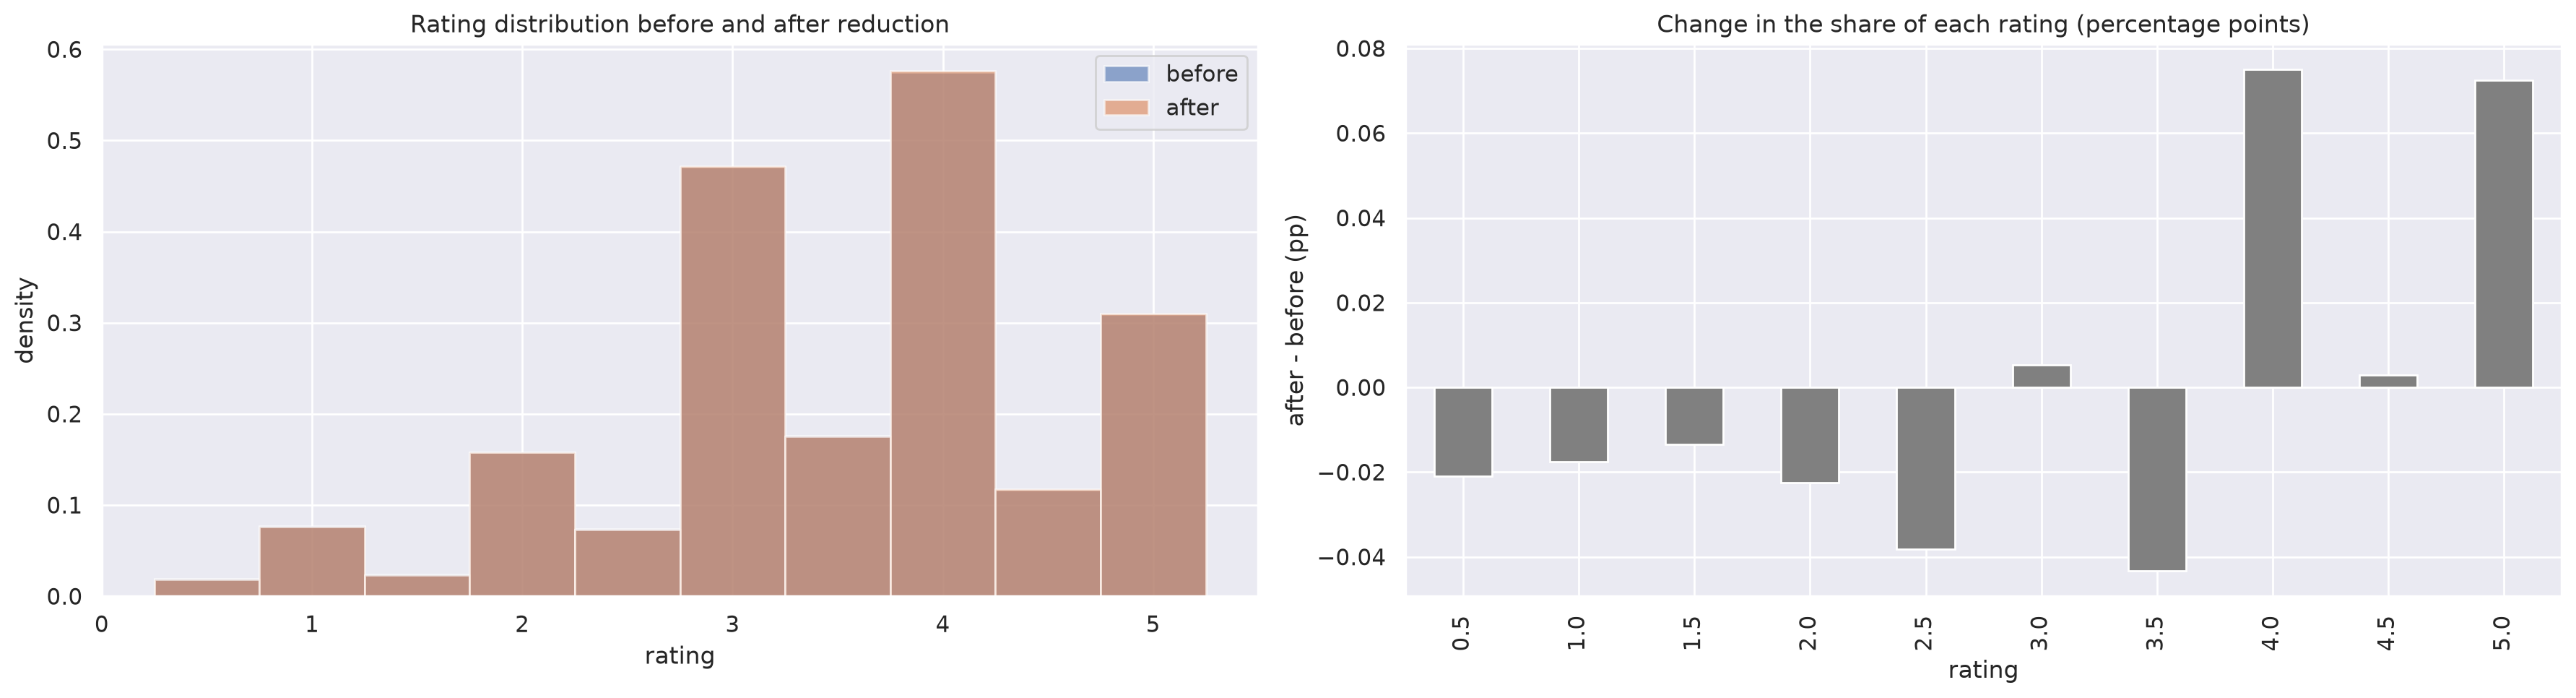

,before,after
Rating,,
0.5,0.0095,0.0093
1.0,0.0384,0.0382
1.5,0.0118,0.0117
2.0,0.0790,0.0788
2.5,0.0370,0.0366
3.0,0.2357,0.2357
3.5,0.0880,0.0875
4.0,0.2876,0.2883
4.5,0.0585,0.0585


mean rating : 3.512 -> 3.516


In [7]:
# 📝 **TASK:** Compare dataset size before and after reduction.

# Step 1: Print the shape of df_rating before reduction
print(f"before : {df_rating.shape},  "
      f"{df_rating.memory_usage(deep=True).sum() / 1024 ** 2:,.0f} MB in memory")

# Step 2: Print the shape of df_rating after reduction
print(f"after  : {df_rating_reduced.shape},  "
      f"{df_rating_reduced.memory_usage(deep=True).sum() / 1024 ** 2:,.0f} MB in memory")
print(f"ratings dropped : {1 - len(df_rating_reduced) / len(df_rating):.1%}")

# The density of the rating matrix is what actually matters for a recommender.
def density(ratings):
    return len(ratings) / (ratings.UserId.nunique() * ratings.MovieId.nunique())

print(f"\ndensity before : {density(df_rating):.3%}")
print(f"density after  : {density(df_rating_reduced):.3%}")

# Step 3: Plot the rating distribution to see if it's still representative
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

bins = np.arange(0.25, 5.5, 0.5)
axes[0].hist(df_rating.Rating, bins=bins, density=True, alpha=0.6, label="before")
axes[0].hist(df_rating_reduced.Rating, bins=bins, density=True, alpha=0.6, label="after")
axes[0].set(title="Rating distribution before and after reduction",
            xlabel="rating", ylabel="density")
axes[0].legend()

comparison = pd.DataFrame({
    "before": df_rating.Rating.value_counts(normalize=True).sort_index(),
    "after": df_rating_reduced.Rating.value_counts(normalize=True).sort_index(),
})
(100 * (comparison["after"] - comparison["before"])).plot.bar(ax=axes[1], color="grey")
axes[1].set(title="Change in the share of each rating (percentage points)",
            xlabel="rating", ylabel="after - before (pp)")
plt.tight_layout()
plt.show()

display(comparison.round(4))
print(f"mean rating : {df_rating.Rating.mean():.3f} -> {df_rating_reduced.Rating.mean():.3f}")

#### Further approaches

**❓ Think About**: What other strategies could you use to reduce the dataset?

After completing the main exercise, try:

- Reducing by random sampling instead of filtering.
- Removing users who only gave extreme ratings (only 1s and 5s).
- Keeping only users from a specific age group or occupation.

> **Answers — pros and cons of the reduction strategies**
>
> | Strategy | Pros | Cons |
> |---|---|---|
> | Drop rarely rated movies | Removes the noisiest part of the catalogue (a mean computed on 3 ratings says nothing) and most of the sparsity | Kills the long tail, i.e. exactly what a recommender is supposed to discover; makes the cold-start problem invisible |
> | Drop inactive users | Every remaining user has enough history to be modelled | The users we drop are the ones a real system struggles with the most |
> | Random sampling of users | Unbiased: the distributions are preserved | Keeps the sparsity; a user kept with only 2 of their 200 ratings is worse than a user dropped |
> | Keep extreme raters out / filter on demographics | Useful to study a specific segment | Deliberately biases the sample; results no longer transfer to the whole population |
>
> **What the two filters actually did here.** The user filter changed nothing:
> MovieLens 10M only contains users with at least 20 ratings, so the dataset was
> already filtered that way by GroupLens. The movie filter dropped 32 % of the
> catalogue (10 677 → 7 259 movies) but only 0.7 % of the ratings — which is the
> long tail in one sentence: a third of the movies carry less than one rating out
> of a hundred. The density of the rating matrix goes from 1.34 % to 1.96 % and
> the rating distribution barely moves (mean 3.512 → 3.516, no rating value
> shifts by more than 0.1 point), so the reduced dataset is still representative.
>
> Note what this reduction does *not* buy: the dataframe itself does not get
> smaller in memory (379 MB against 305 MB, because filtering copies and keeps
> the original index). To actually save memory one has to downcast the dtypes
> (`int32`/`float32`) or store the matrix in a sparse structure — the reduction
> is about signal quality and matrix density, not about RAM.

In [8]:
# Import data from movielens dataset

# Keep the rating counts of the big dataset: they are used further down to
# compare its long tail with the one of the 100K version.
movie_counts_10m = movie_counts.copy()

# From here on we work with MovieLens 100K, which `load_data` returns already
# split into a train and a test set.
del df_rating, df_rating_reduced, df_items, df_users, df_rating_test
gc.collect()

df_rating, df_rating_test, df_users, df_items, df_matrix, n_users, n_items = load_data()

print(f"train ratings : {len(df_rating):,}")
print(f"test ratings  : {len(df_rating_test):,}")
print(f"users         : {n_users:,}")
print(f"movies        : {n_items:,}")
df_rating.head()

train ratings : 80,000
test ratings  : 20,000
users         : 943
movies        : 1,682


,UserId,MovieId,Rating,Timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,244,51,2,880606923
3,166,346,1,886397596
4,298,474,4,884182806


In order to compose the training data as we have seen in lectures, we need to create a matrix having users in rows and movies in columns (or its equivalent transpose matrix).

This can be easily done by a pivot operator in pandas.

In [9]:
df_rating.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   UserId     80000 non-null  int64
 1   MovieId    80000 non-null  int64
 2   Rating     80000 non-null  int64
 3   Timestamp  80000 non-null  int64
dtypes: int64(4)
memory usage: 2.4 MB


### 📝 Exercise: Transform Ratings Table into a User-Movie Matrix

#### 📌 Goal:
Convert the ratings table into a user-movie matrix, where:

Rows represent users
Columns represent movies
Cells contain ratings, with NaN where users have not rated the movie
--- 

#### 🎯 Your Task
1. **Understand the Structure of the Data**
Use `.head()` to inspect the ratings DataFrame.
Identify which columns will be used to pivot the data.

2. **Transform the Ratings Table**
Use pivot() or pivot_table() in Pandas to reshape the DataFrame.
Ensure that:
Users are in rows (index="UserId")
Movies are in columns (columns="MovieId")
Ratings are filled in (values="Rating")
Handle missing ratings by keeping NaN for unwatched movies.

3. **Check the New Matrix**
Print the shape of the matrix.
Display the first few rows.

---

❓ Think About
Why do we keep NaN instead of filling with zeros?
How can we later use this matrix in a recommender system?
What happens if a user or a movie has no ratings?

---

💡 Tips
Use the pivot_table() function to handle potential duplicate entries.
Consider using the fill_value parameter to handle missing values.

---

🚀 Bonus Challenge
Modify the matrix to fill NaN values with the movie's average rating instead of keeping NaNs.


In [10]:
# Insert your code here

# 1. Inspect the data: we pivot UserId (rows) x MovieId (columns) on Rating.
display(df_rating.head())

# 2. Transform the ratings table. `pivot_table` also copes with duplicated
#    (user, movie) pairs, which `pivot` would reject.
df_matrix = df_rating.pivot_table(index="UserId", columns="MovieId", values="Rating")

# 3. Check the new matrix.
print(f"matrix shape : {df_matrix.shape} (users x movies)")
print(f"filled cells : {df_matrix.notna().sum().sum():,} out of {df_matrix.size:,}"
      f" ({df_matrix.notna().sum().sum() / df_matrix.size:.2%})")
df_matrix.head()

,UserId,MovieId,Rating,Timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,244,51,2,880606923
3,166,346,1,886397596
4,298,474,4,884182806


matrix shape : (943, 1650) (users x movies)
filled cells : 80,000 out of 1,555,950 (5.14%)


MovieId,1,2,3,4,5,6,7,8,9,10,...,1672,1673,1674,1675,1676,1677,1678,1679,1681,1682
UserId,,,,,,,,,,,,,,,,,,,,,
1,NaN,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df_matrix

MovieId,1,2,3,4,5,6,7,8,9,10,...,1672,1673,1674,1675,1676,1677,1678,1679,1681,1682
UserId,,,,,,,,,,,,,,,,,,,,,
1,NaN,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
940,NaN,NaN,NaN,2.0,NaN,NaN,4.0,5.0,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
941,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


> **Answers — why `NaN` and not `0`?**
>
> * A zero is a *rating*: it would mean "this user hated this movie". A `NaN`
>   means "we do not know", which is the truth for 94 % of the cells. Filling
>   with zeros drags every average down and teaches the model that unseen
>   movies are bad ones.
> * The matrix is the training data of every model of the course: collaborative
>   filtering learns *only* from the observed entries, and the missing ones are
>   precisely what we want to predict.
> * A user (or a movie) with no rating at all becomes an all-`NaN` row (column):
>   nothing can be learnt about them, which is the *cold-start* problem — it is
>   handled by the non-personalised recommender we build below, and by the
>   content-based model of Session 02.
>
> *Bonus:* filling with the mean rating of the movie
> (`df_matrix.fillna(df_matrix.mean(axis=0))`) is a reasonable baseline for
> algorithms that cannot cope with missing values (PCA, plain SVD), but it
> invents data: it makes every user look average on everything they have not
> seen.

As one can see, the matrix is full of nan values.

## Exploratory data analysis

Let's have a look at the data, just to get some insights that will help us in the rest of the course.

### Rating distribution

First of all, we want to study the distributions of all ratings. This is useful to see whether in our database we have a particularly unbalanced rating, or if on average all movies are equally appreciated.

There are several ways to do so, all enlightening a slightly different aspect of the data. 
Recall that the rating matrix is _sparse_ (_i.e._ plenty of nan's).

Consider the following,

1. **Histograms**: You can plot a histogram of the non-zero values in your sparse matrix to see their distribution.

2. **Density plots**: Another way to visualize the distribution of values in a sparse matrix is to plot a density plot, which is a smoothed version of a histogram.

3. **Box plots**: A box plot can give you a good idea of the distribution of values in your sparse matrix, especially if you have a large number of non-zero values.

4. **Scatter plots**: You can also plot the non-zero values in your sparse matrix as a scatter plot, which can give you an idea of the distribution and relationship between different values.

Let's look at the density plot (we leave the other plots as exercise).

/tmp/ipykernel_1739/3042612249.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(non_zero_values.data, shade=True)


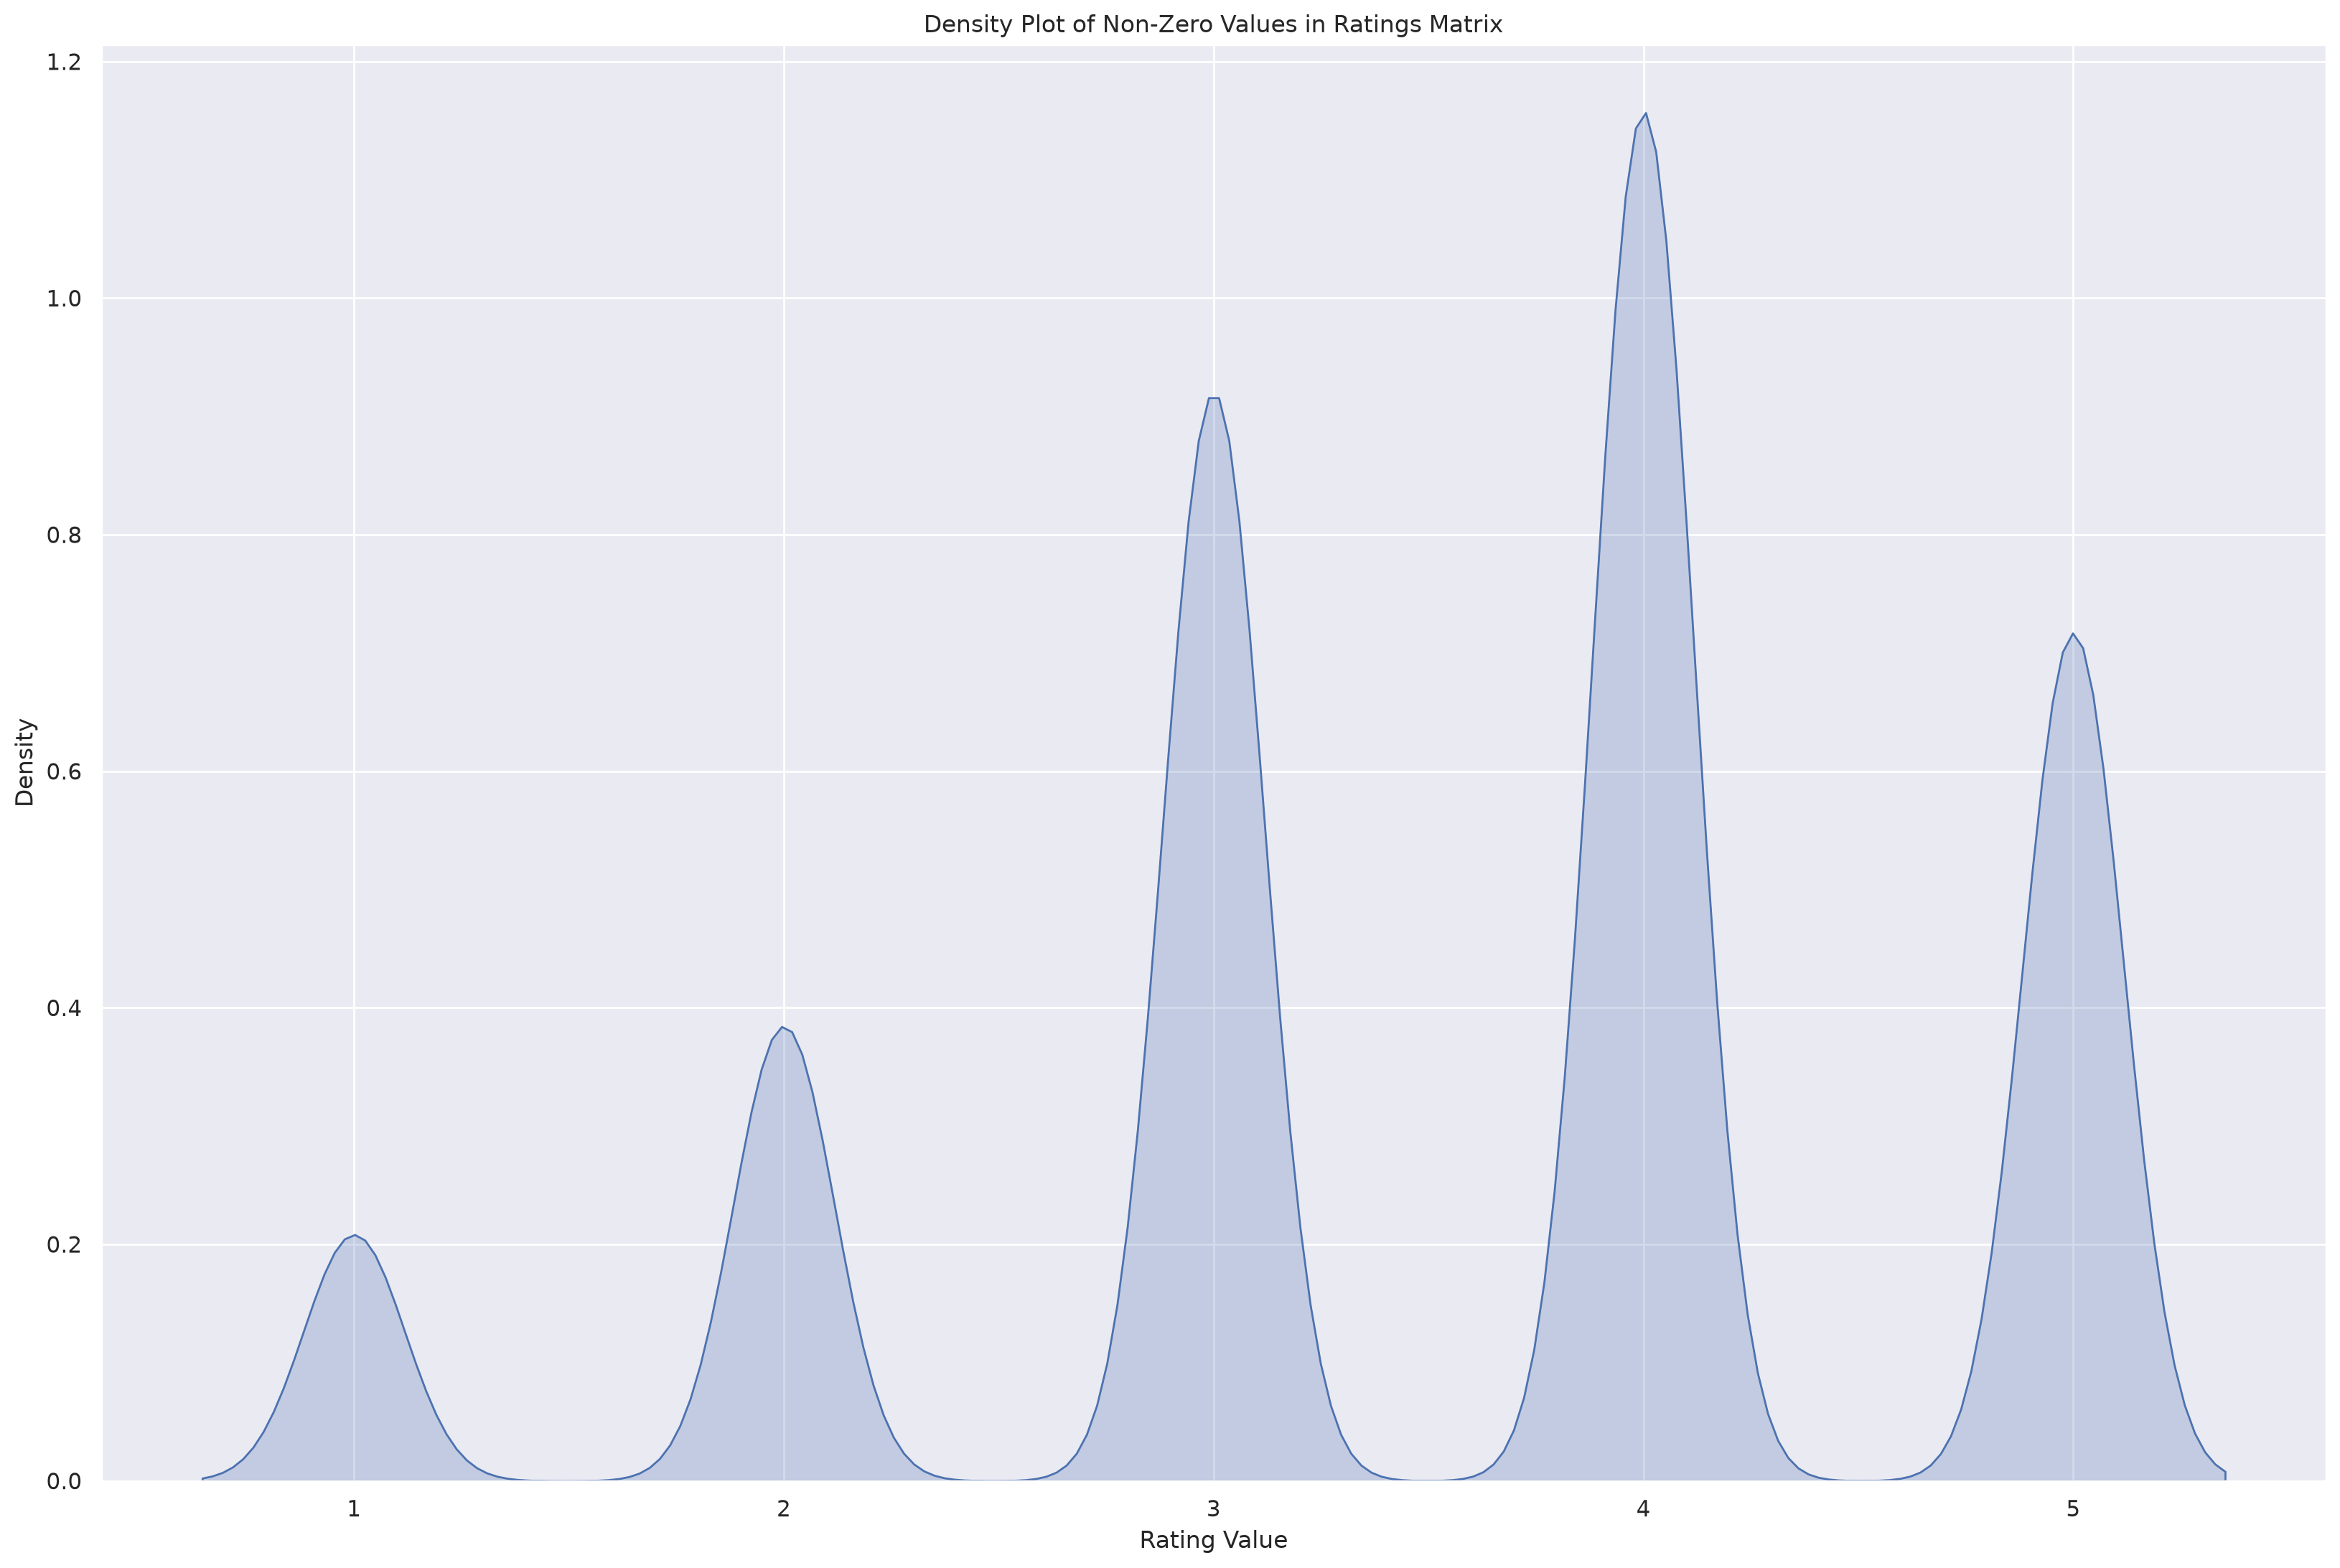

In [12]:
non_zero_values = csr_matrix(df_matrix.T.fillna(0).values)

# Plot the density plot of the non-zero values
sns.kdeplot(non_zero_values.data, shade=True)

# Add a title and labels to the plot
plt.title("Density Plot of Non-Zero Values in Ratings Matrix")
plt.xlabel("Rating Value")
plt.ylabel("Density")

# Show the plot
plt.show()

### Explaining the Density Plot of the Ratings Matrix
#### 1️⃣ What Are We Plotting?
In this density plot, we visualise the distribution of ratings (excluding NaNs) in the user-movie matrix.

The x-axis represents rating values (e.g., 1–5).
The y-axis represents the density (relative frequency of ratings).
The curve shows how common each rating is in the dataset.
#### 2️⃣ Key Observations from the Plot
If the peak is around 4 or 5, this suggests that most users tend to give high ratings (positive bias).
If the plot is skewed towards lower values, it means negative ratings are more frequent.
If the plot has multiple peaks, it suggests that users tend to rate movies at specific levels (e.g., mostly 1, 3, or 5).
A flat distribution would indicate that all ratings are equally common (which is unlikely).
#### 3️⃣ What Does This Mean for Recommender Systems?
If the distribution is skewed towards high ratings, the dataset has a positivity bias (users rarely leave negative reviews).
If ratings are concentrated around one value, predictions may be less informative (e.g., if everyone rates 4, predicting a 4 adds no real insight).
If ratings are well spread, the model can better distinguish between good and bad movies.
**👉 This analysis helps us decide whether we need to normalise the data or adjust the recommendation approach.**

#### 📝 Questions
- Based on the density plot, do you think users are biased toward high ratings?
- Why is it important to check for rating imbalance before building a recommendation model?
- What might happen if our recommender only suggests movies with high ratings?
- How would you modify the dataset to make recommendations more balanced?

### Rating frequency

#### Rating frequency per movie

Another interesting feature to study is the rating frequency of movies. 
Indeed, we are interested in understanding whether people are always rating the same movies (_i.e._ the popular ones) or if the rating distribution is evenly distributed across all movies.

This can be determined by looking at the count of rating per movie.

In [13]:
movie_rat_freq = pd.DataFrame(df_rating.groupby("MovieId").size(), columns=["count"])
movie_rat_freq.head()

,count
MovieId,
1,371
2,104
3,68
4,159
5,74


We are ready to plot the rating frequency per movie.

Text(0, 0.5, 'number of ratings')

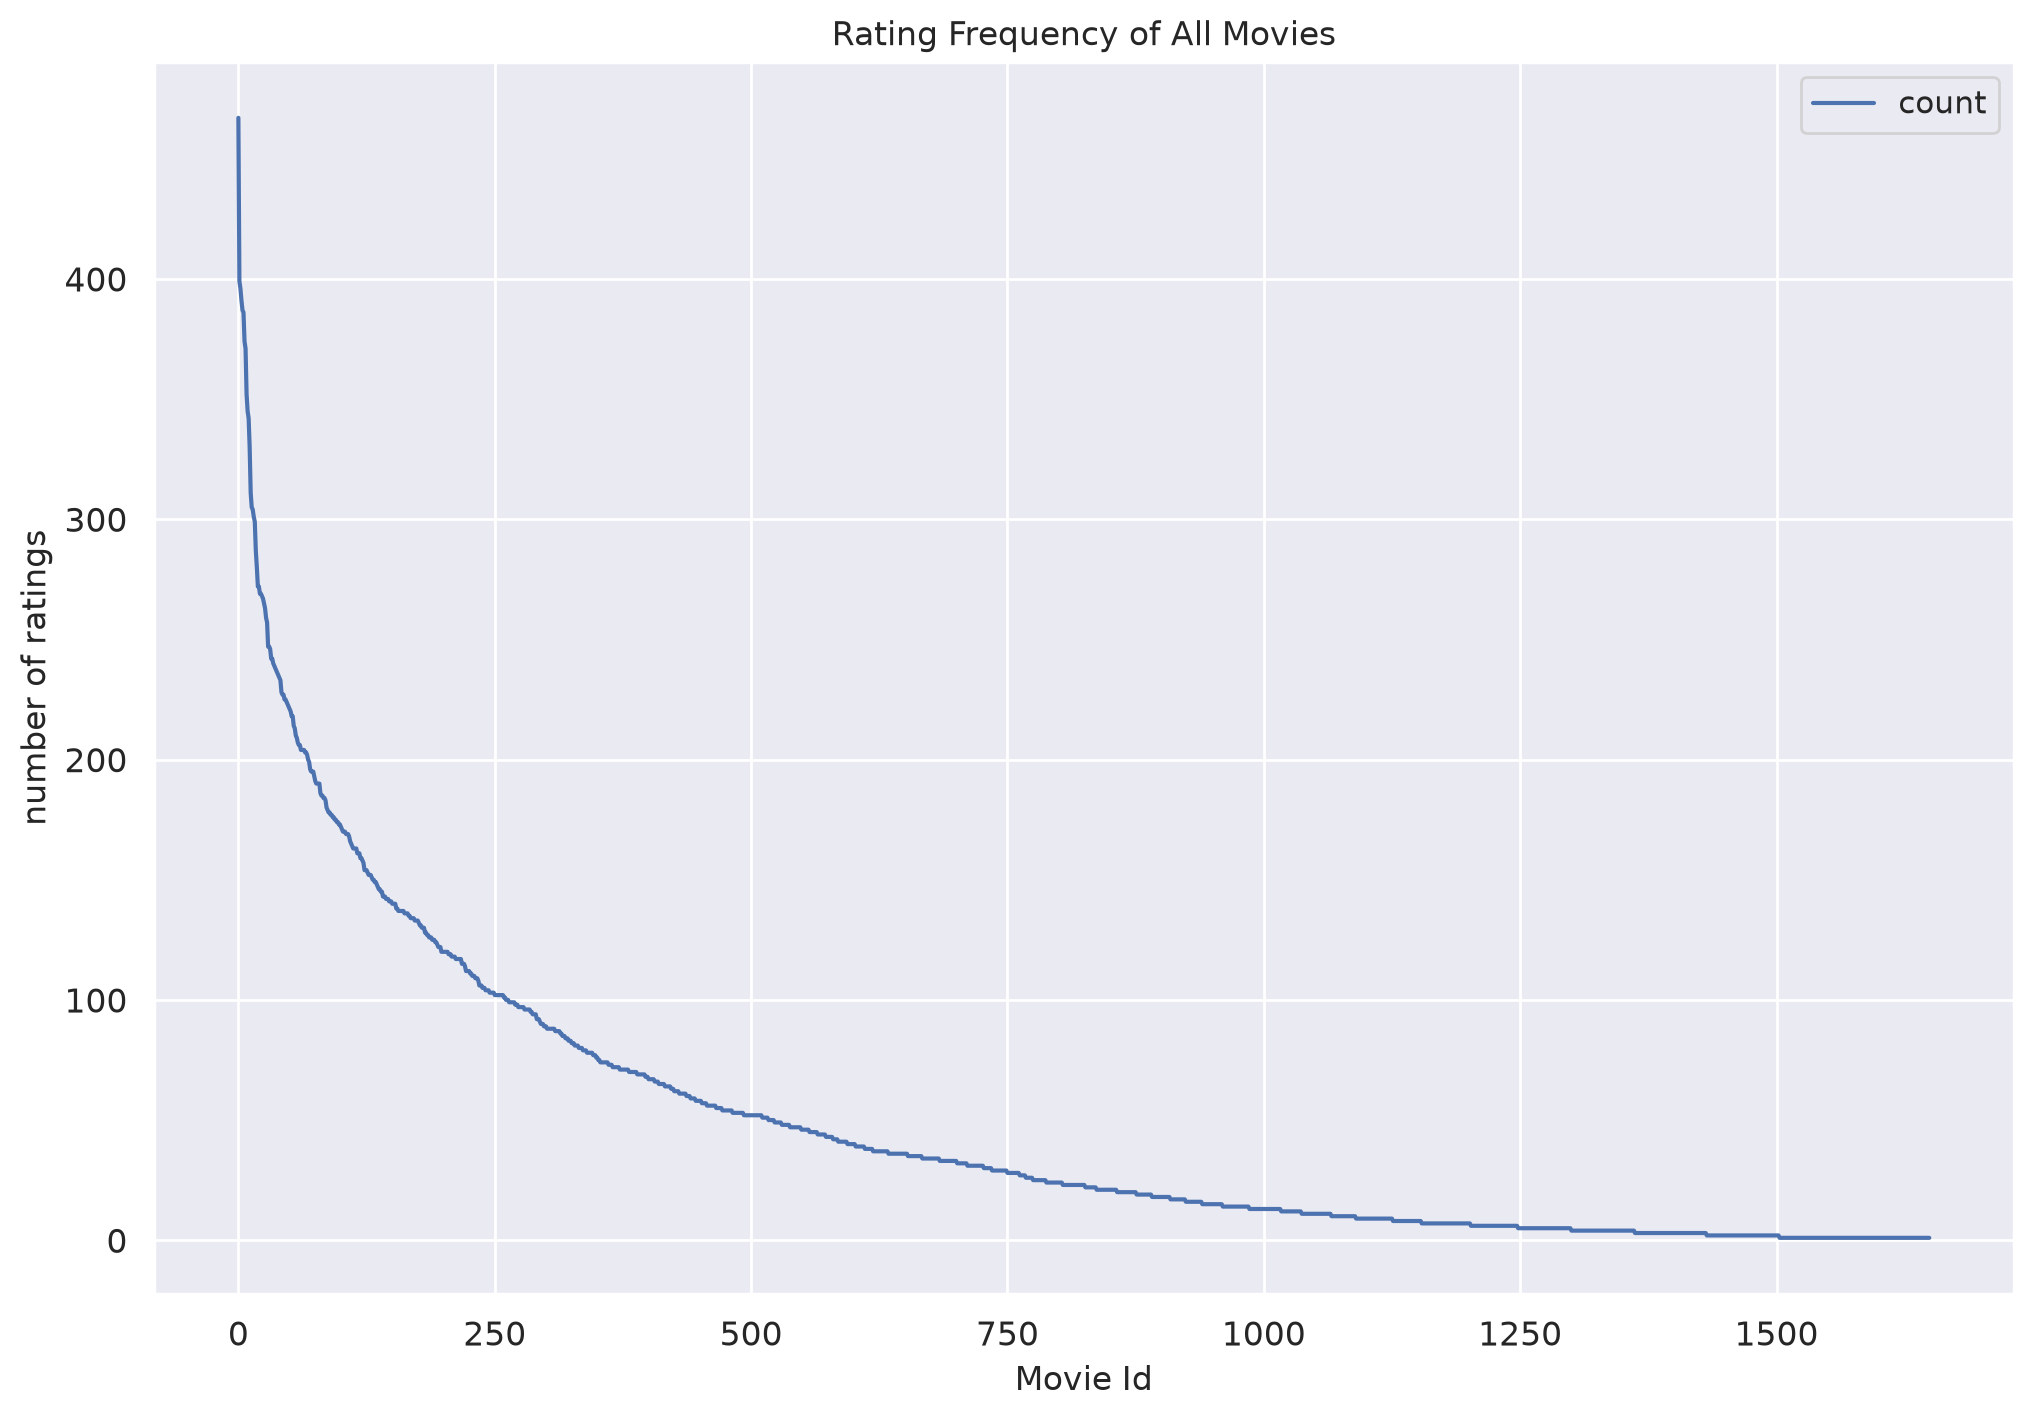

In [14]:
# plot rating frequency of all movies
ax = (
    movie_rat_freq.sort_values("count", ascending=False)
    .reset_index(drop=True)
    .plot(figsize=(12, 8), title="Rating Frequency of All Movies", fontsize=12)
)
ax.set_xlabel("Movie Id")
ax.set_ylabel("number of ratings")

The distribution of ratings among movies often satisfies a property in real-world settings, which is referred to as the _long-tail property_. According to this property, only a small fraction of the items are rated frequently. Such items are referred to as popular items. The vast majority of items are rated rarely. This results in a highly skewed distribution of the underlying ratings.

Let's plot the same distribution but with log scale.

Text(0, 0.5, 'number of ratings (log scale)')

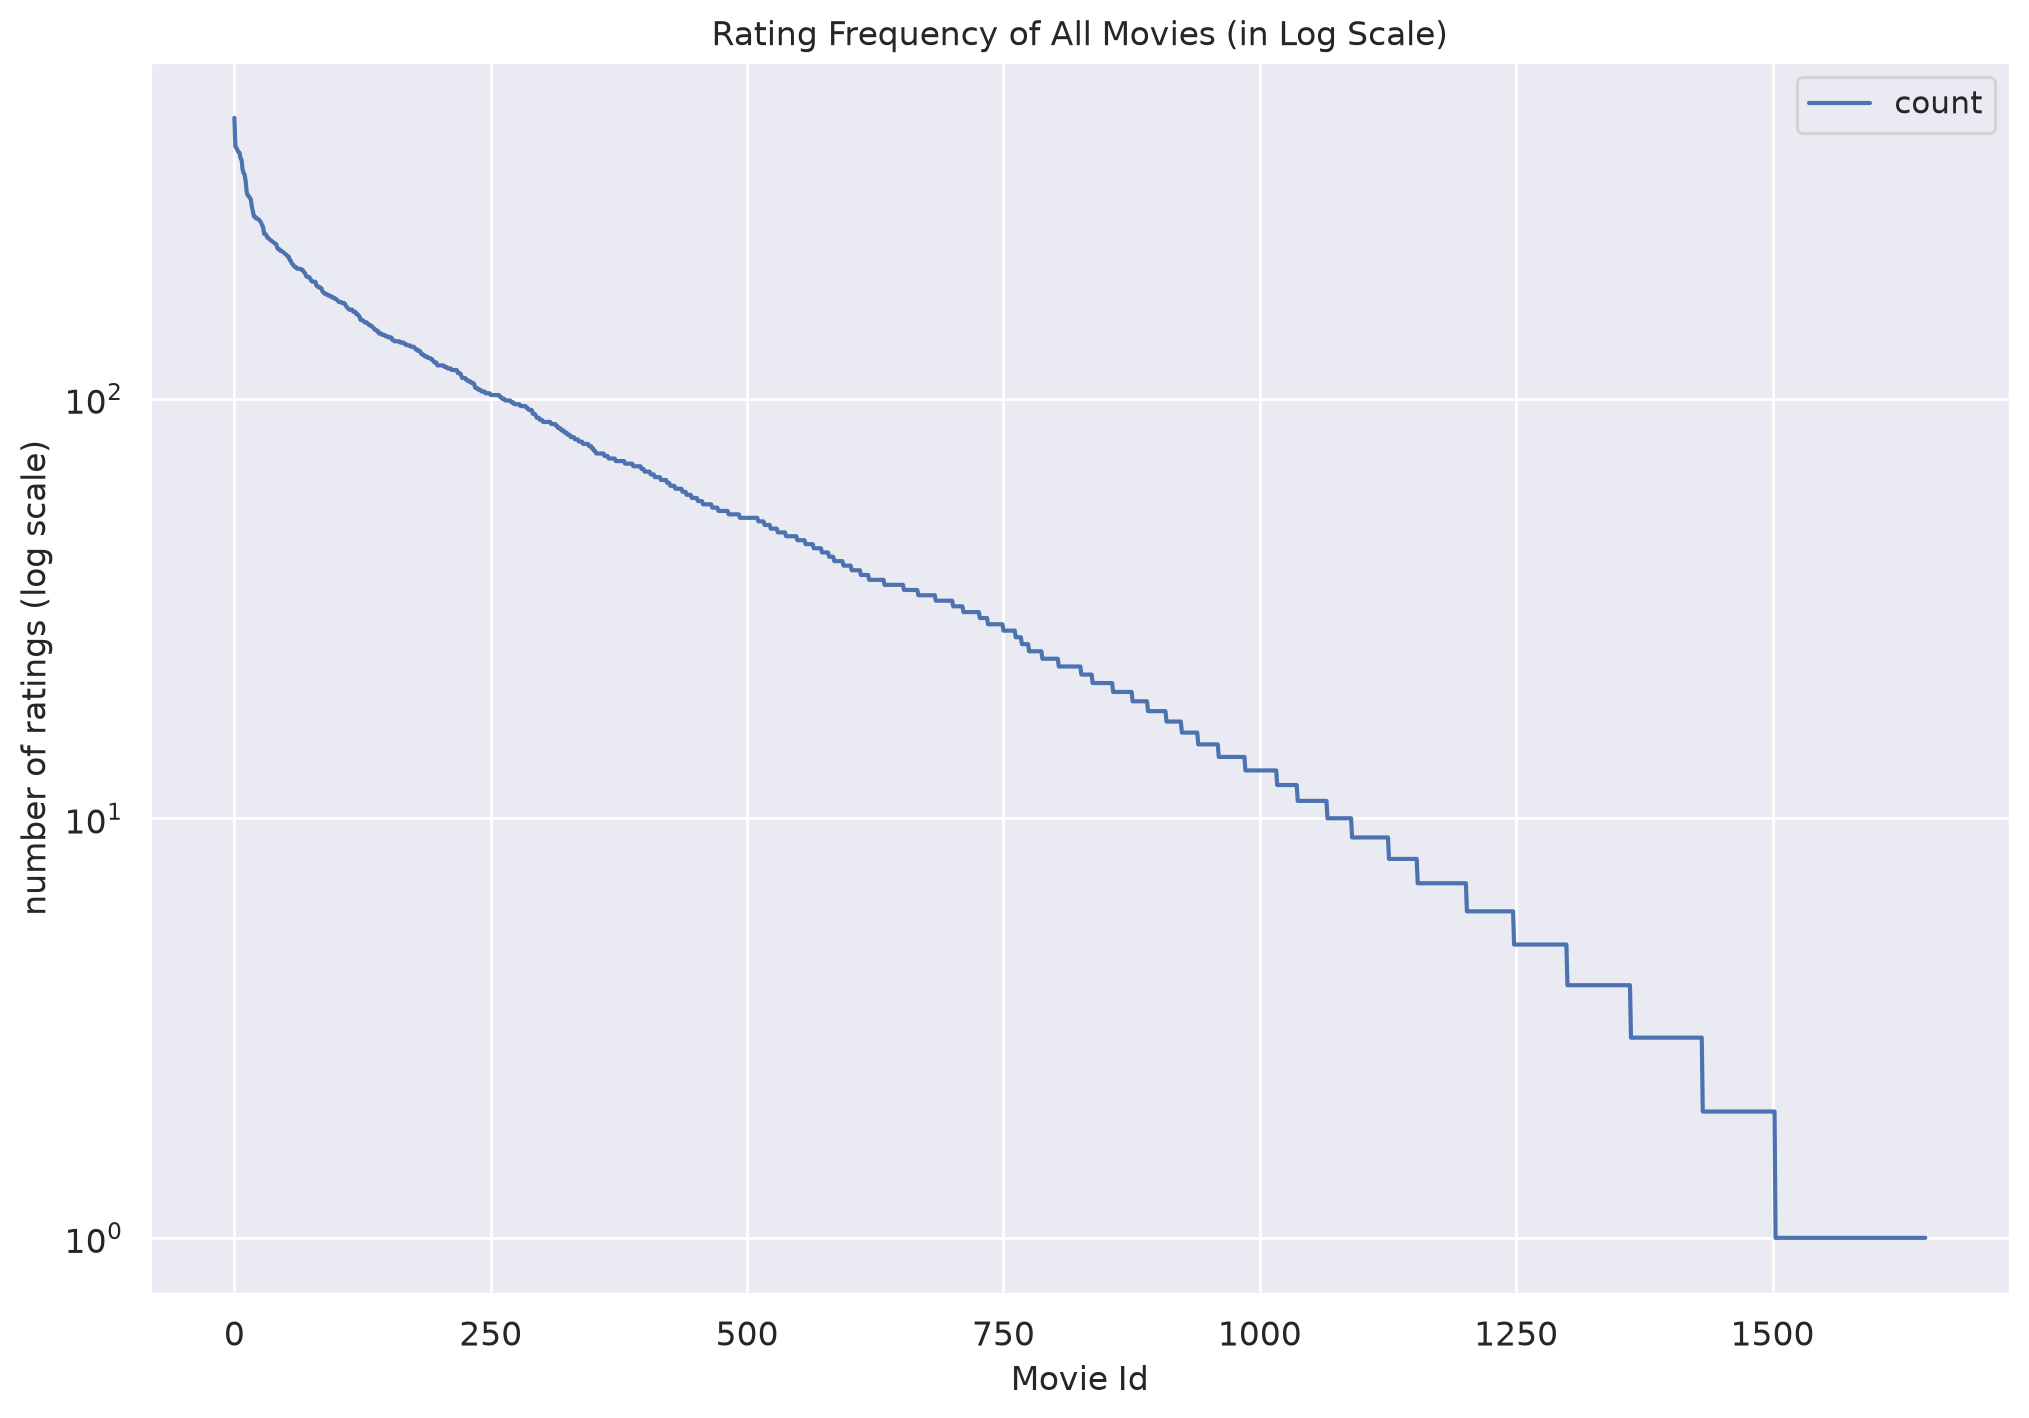

In [15]:
# plot rating frequency of all movies in log scale
ax = (
    movie_rat_freq.sort_values("count", ascending=False)
    .reset_index(drop=True)
    .plot(
        figsize=(12, 8),
        title="Rating Frequency of All Movies (in Log Scale)",
        fontsize=12,
        logy=True,
    )
)
ax.set_xlabel("Movie Id")
ax.set_ylabel("number of ratings (log scale)")

We can see that ~$700$ movies out of $1682$ are rated less than only $10$ times. Let's look closer by displaying top quantiles of rating counts.

In [16]:
movie_rat_freq["count"].quantile(np.arange(1, 0.6, -0.05))

1.00    467.00
0.95    184.55
0.90    136.00
0.85    103.00
0.80     81.00
0.75     65.00
0.70     52.00
0.65     43.00
Name: count, dtype: float64

So about $1\%$ of movies have roughly $484$ or more ratings, $5\%$ have $188$ or more, and $20\%$ have $80$ or more. 

This is an effect of the reduced dataset we have chosen.

Try to import the complete dataset from [movielens](https://grouplens.org/datasets/movielens/) and repeat this very same analysis. 

You will find an even longer tail effect, which leads to the choice of the reduced dataset.

This is convenient for a two-fold reason:

1. Memory issue: we don't want to run into the “MemoryError” during model training
2. Improve model performance: lesser known movies have ratings from fewer viewers, making the pattern more noisy. Dropping out less known movies can improve recommendation quality.

### Explaining Rating Frequency Per Movie & The Long-Tail Property

#### 1️⃣ Why Are We Studying Rating Frequency Per Movie?
In recommender systems, not all movies receive the same number of ratings. Some are extremely popular, while others are rarely rated.

This imbalance can have a major impact on how recommendations are generated:

* Popular movies dominate recommendations.
* Niche movies struggle to get recommended, even if they match user preferences.
* The dataset becomes biased toward mainstream content.

#### 2️⃣ Understanding The Long-Tail Property
**📌 Definition:**

* A few popular movies receive a huge number of ratings.
* Most other movies have very few ratings.
* When plotted, this distribution forms a long-tail shape.

**📌 What Does This Mean?**

* The head (left side of the plot) = Popular movies with many ratings.
* The tail (right side of the plot) = Niche movies with few ratings.
* The dataset is highly skewed → a small fraction of movies dominate the majority of ratings.

**📌 Real-World Examples:**

* On Netflix, a handful of blockbuster movies get most of the attention.
* On Spotify, a few artists dominate global streams, while thousands of indie artists get minimal exposure.

#### 3️⃣ How To Interpret The Log-Scale Plot?

**🔍 Why Use a Log Scale?**
If we plot the raw rating counts, popular movies dominate the graph, making it hard to see the long-tail effect.
A log scale compresses large values, so both popular and rare movies are visible on the same graph.

#### 4️⃣ Why Is The Long-Tail Property Important?
* Popular items dominate recommendations.
* Niche movies struggle to be recommended.
* Users with unique preferences get fewer relevant suggestions.

**👉 Recommender systems must address this issue to improve diversity and personalisation!**

#### 📝 Questions for Students

* How does the long-tail effect impact the quality of recommendations?
* What happens if a recommender system only recommends popular items?
* How could you design a system that recommends more niche movies?
* What are some strategies to balance popularity and diversity in recommendations?

---

#### Rating frequency per user

At this stage, it is useful to study the rating frequency per user.

In [17]:
user_rat_freq = pd.DataFrame(df_rating.groupby("UserId").size(), columns=["count"])
user_rat_freq.head()

,count
UserId,
1,228
2,51
3,44
4,17
5,154


Text(0, 0.5, 'number of ratings')

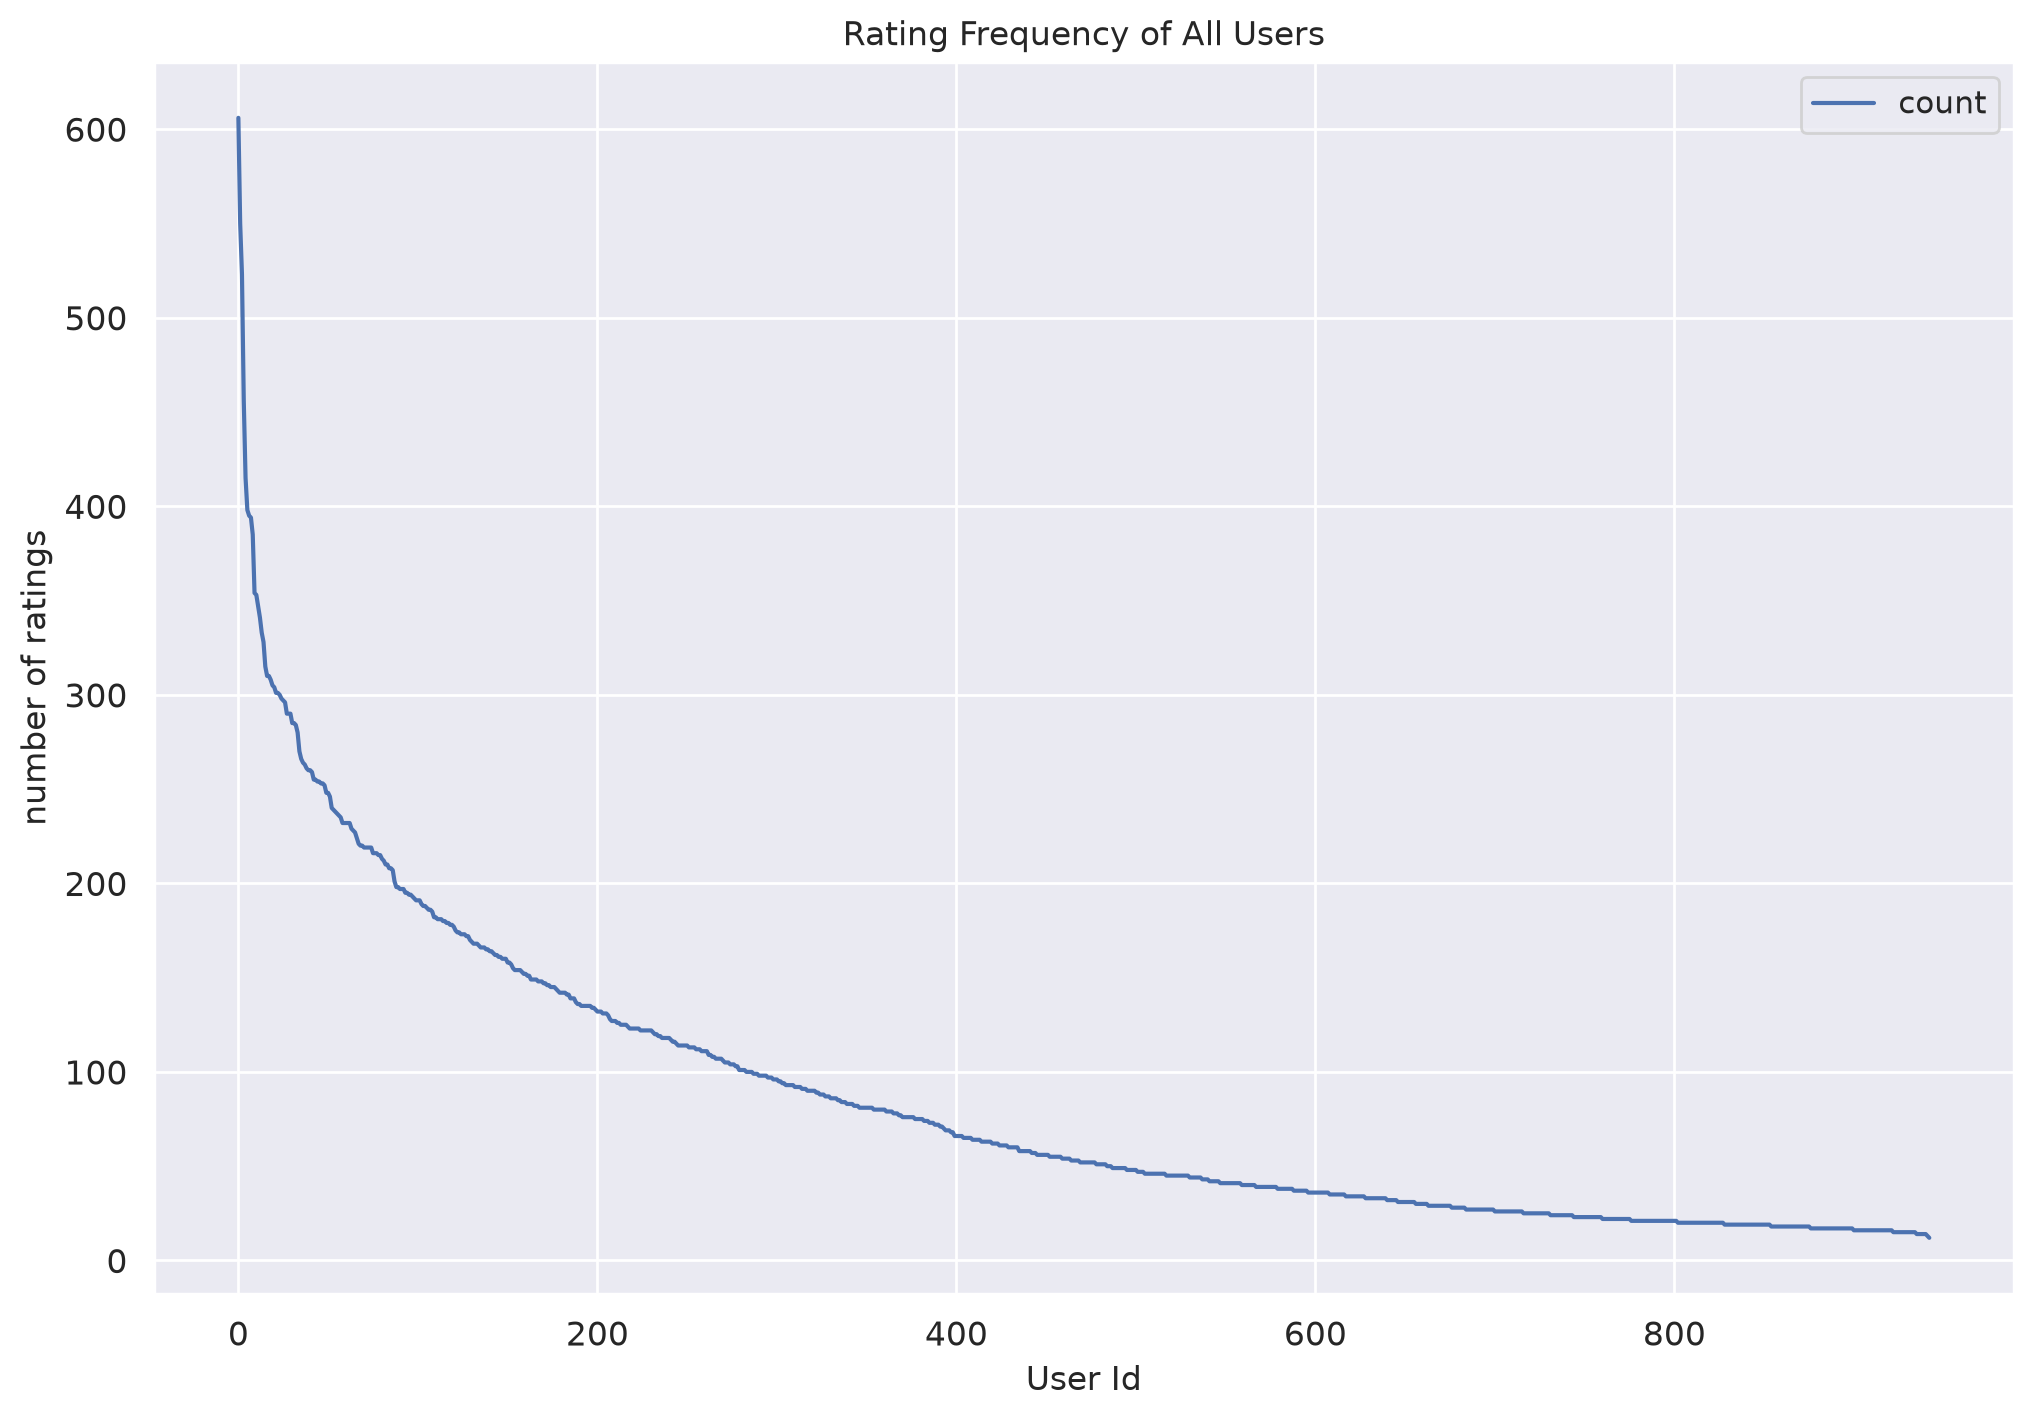

In [18]:
# plot rating frequency of all users
ax = (
    user_rat_freq.sort_values("count", ascending=False)
    .reset_index(drop=True)
    .plot(figsize=(12, 8), title="Rating Frequency of All Users", fontsize=12)
)
ax.set_xlabel("User Id")
ax.set_ylabel("number of ratings")

We can see that the distribution of ratings by users is very similar to the distribution of ratings among movies.
Again, we can see the long-tail effect, less pronounced than in the movie distribution, but still there.

This means that few users give a lot of feedbacks on movies they see (they are called "engaged users"). Indeed, only a very small fraction of users are very actively engaged with rating movies that they watched. Vast majority of users are not interested in rating movies.

In [19]:
user_rat_freq["count"].quantile(np.arange(1, 0.5, -0.05))

1.00    606.0
0.95    252.9
0.90    194.8
0.85    163.7
0.80    136.6
0.75    118.5
0.70    100.4
0.65     86.3
0.60     75.2
0.55     61.1
Name: count, dtype: float64

Text(0, 0.5, 'number of ratings (log scale)')

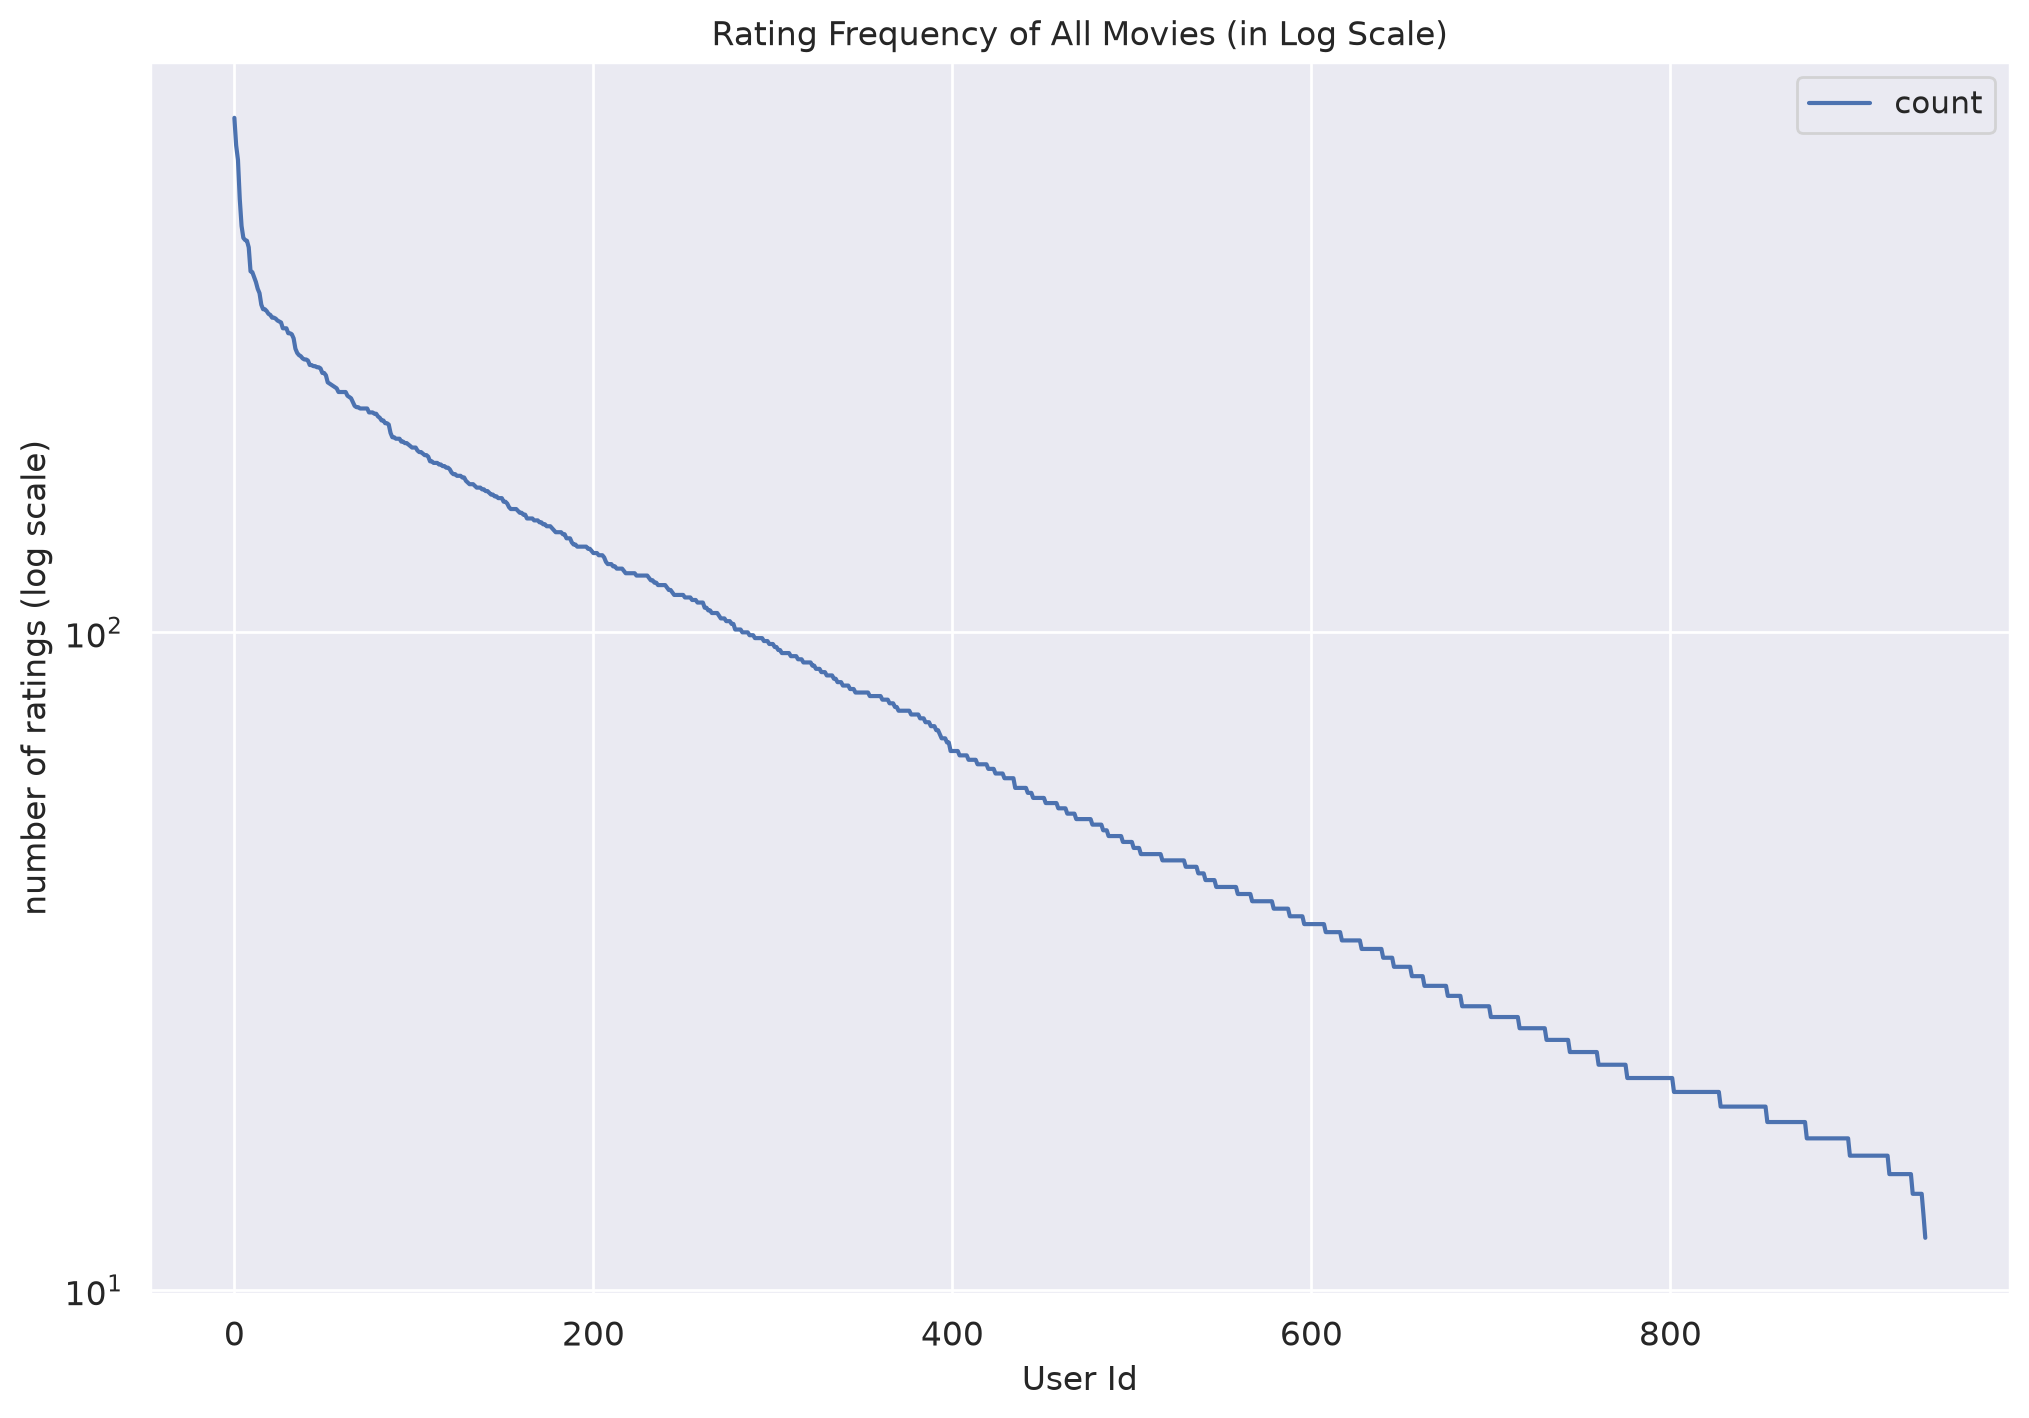

In [20]:
# plot rating frequency of all users in log scale
ax = (
    user_rat_freq.sort_values("count", ascending=False)
    .reset_index(drop=True)
    .plot(
        figsize=(12, 8),
        title="Rating Frequency of All Movies (in Log Scale)",
        fontsize=12,
        logy=True,
    )
)
ax.set_xlabel("User Id")
ax.set_ylabel("number of ratings (log scale)")

#### Exercise

Repeat the very same analysis for the bigger version of the movielens dataset, the one that can be downloaded at [http://files.grouplens.org/datasets/movielens/ml-10m.zip](http://files.grouplens.org/datasets/movielens/ml-10m.zip).

Show that the long-tail effect is much more evident.

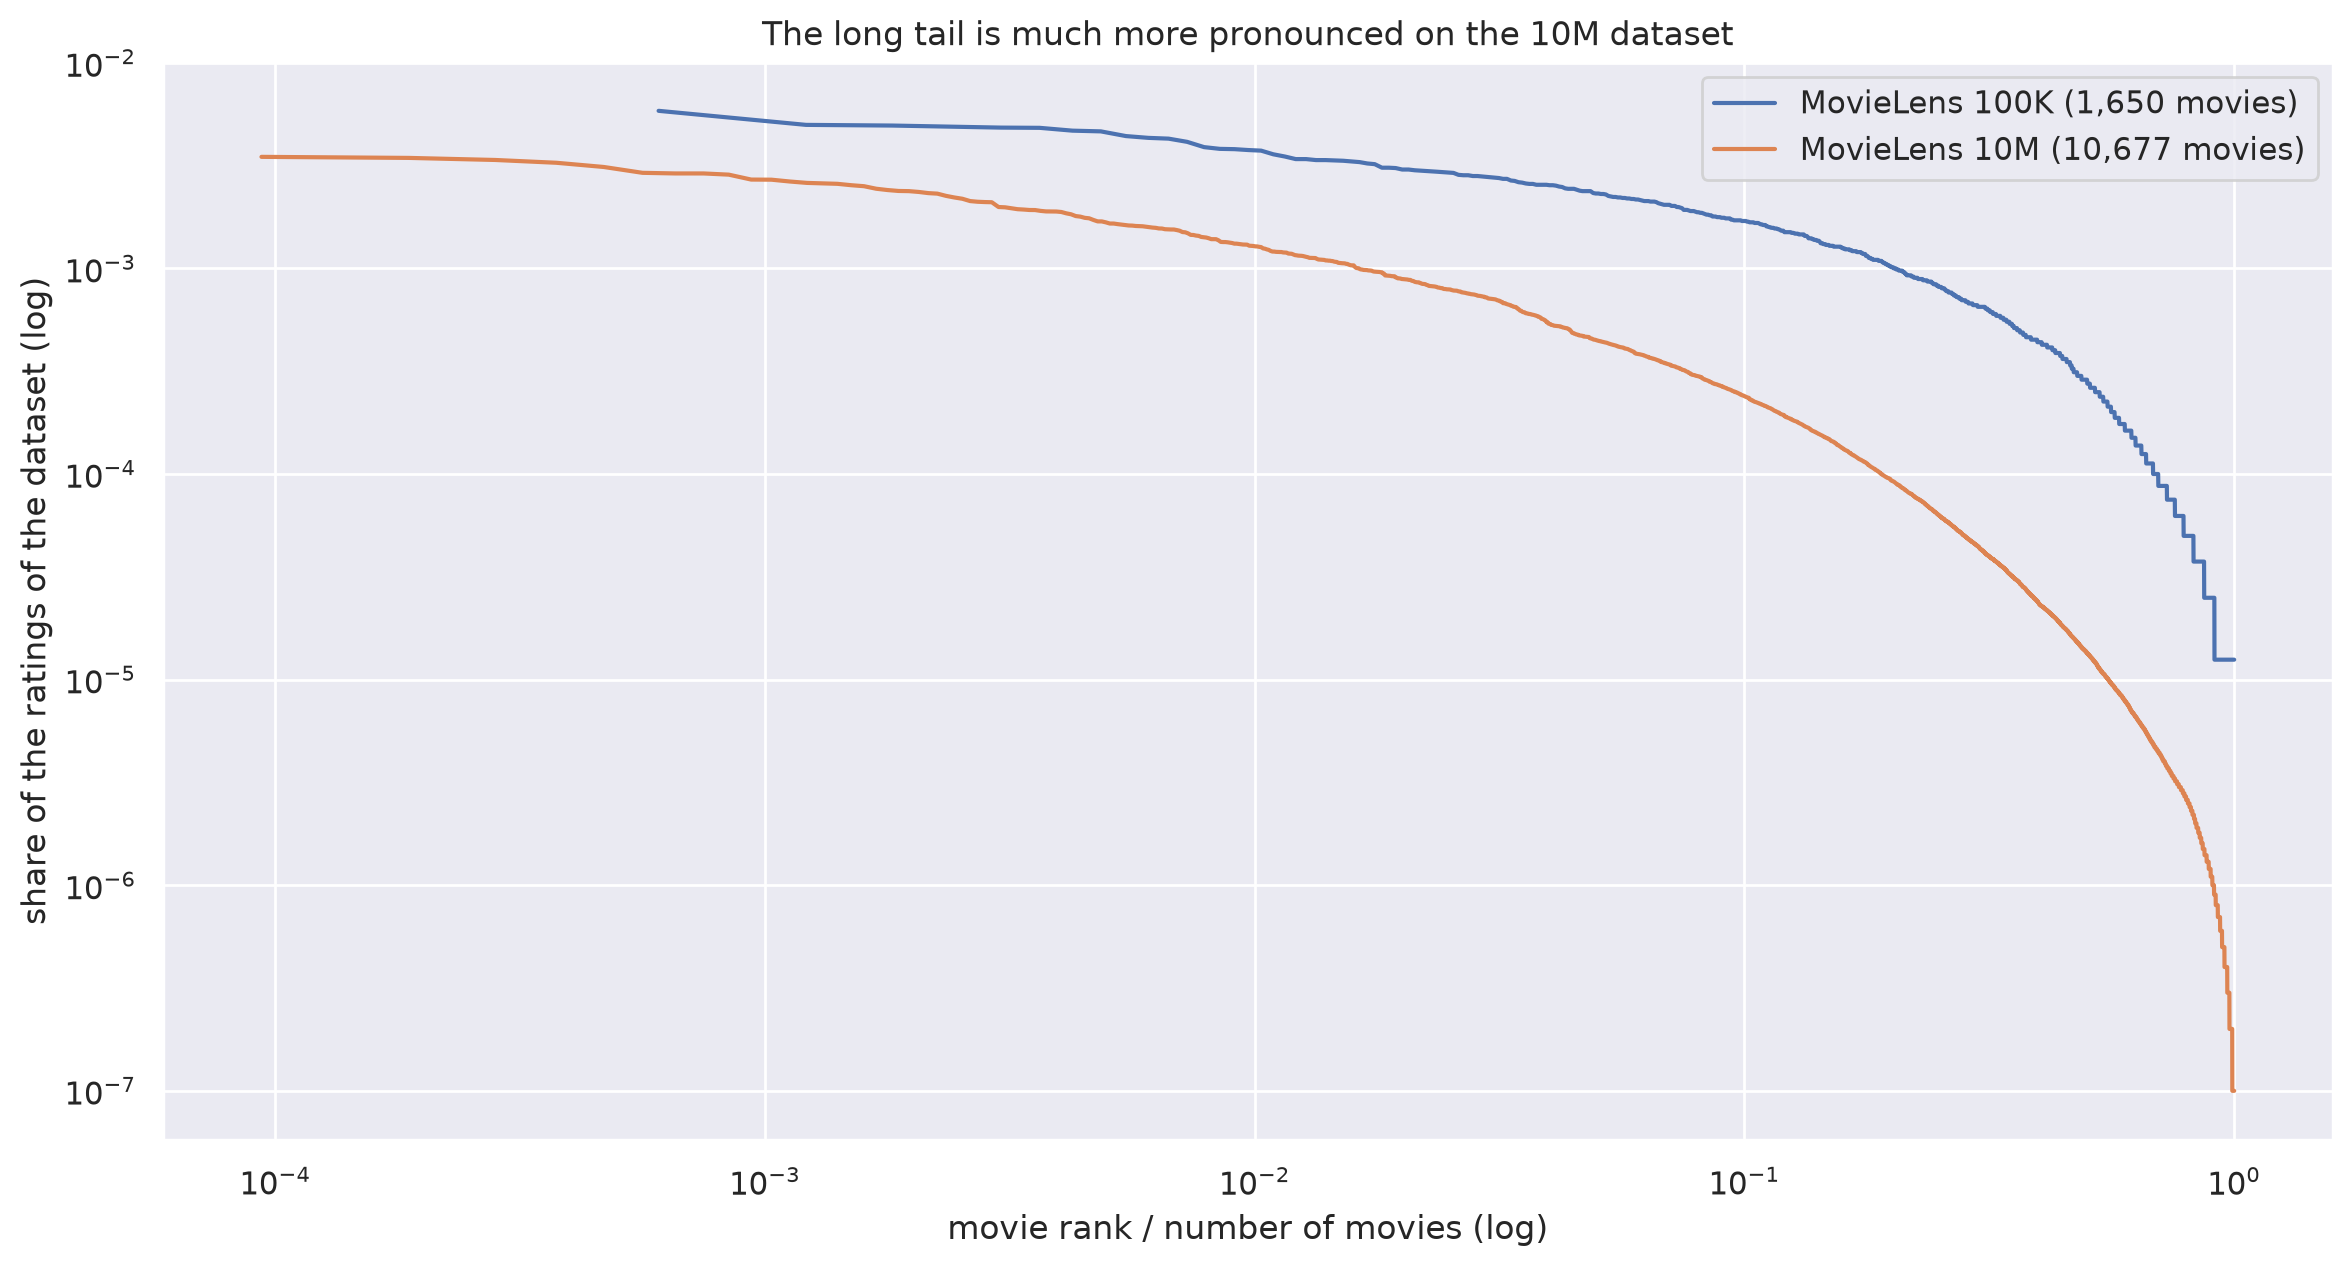

,MovieLens 100K,MovieLens 10M
movies,1650.000,10677.000
share of ratings held by the top 1%,0.072,0.199
share of movies with < 10 ratings,0.339,0.091
median ratings per movie,23.000,135.000


In [21]:
# The long tail of MovieLens 100K compared with the one of MovieLens 10M.
# `movie_counts_10m` was computed on the 10-million-rating dataset above.
movie_rat_freq_100k = df_rating.groupby("MovieId").size().sort_values(ascending=False)
movie_rat_freq_10m = movie_counts_10m.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
for name, counts in [("MovieLens 100K", movie_rat_freq_100k),
                     ("MovieLens 10M", movie_rat_freq_10m)]:
    share = np.arange(1, len(counts) + 1) / len(counts)  # rank as a share of the catalogue
    ax.plot(share, counts.values / counts.sum(), label=f"{name} ({len(counts):,} movies)")
ax.set(xscale="log", yscale="log", xlabel="movie rank / number of movies (log)",
       ylabel="share of the ratings of the dataset (log)",
       title="The long tail is much more pronounced on the 10M dataset")
ax.legend()
plt.show()

summary = pd.DataFrame({
    "MovieLens 100K": [
        len(movie_rat_freq_100k),
        movie_rat_freq_100k.head(int(0.01 * len(movie_rat_freq_100k))).sum() / movie_rat_freq_100k.sum(),
        (movie_rat_freq_100k < 10).mean(),
        movie_rat_freq_100k.median(),
    ],
    "MovieLens 10M": [
        len(movie_rat_freq_10m),
        movie_rat_freq_10m.head(int(0.01 * len(movie_rat_freq_10m))).sum() / movie_rat_freq_10m.sum(),
        (movie_rat_freq_10m < 10).mean(),
        movie_rat_freq_10m.median(),
    ],
}, index=["movies", "share of ratings held by the top 1%",
          "share of movies with < 10 ratings", "median ratings per movie"])
display(summary.round(3))

> **Answer.** The concentration is much stronger on the large dataset: the top
> 1 % of the movies hold **20 %** of the ratings in MovieLens 10M against **7 %**
> in MovieLens 100K, and the log-log curve is visibly steeper. The head is
> heavier, which is what "the long-tail effect is more evident" means.
>
> One number goes the other way and is worth reading carefully: 34 % of the
> movies of the 100K version have fewer than 10 ratings, against 9 % in the 10M
> version (median: 23 ratings per movie against 135). That is a sampling effect,
> not a contradiction — the 100K dataset spreads a hundred times fewer ratings
> over a sixth of the catalogue, so *everything* is rarer. The shape of the
> distribution (a few blockbusters capturing most of the attention) is the same,
> and it gets more extreme as the catalogue grows.

### Calculate the most popular movie

Let's look at the movie colums. We can create a vector, summing over the colums, to get a _total score_ measuring how much that movie has been rated.

Thanks to pandas methods, this can be done by one line of code.

In [22]:
movie_scores = df_matrix.sum(axis=0, skipna=True)
movie_scores

MovieId
1       1436.0
2        336.0
3        207.0
4        572.0
5        239.0
         ...  
1677       3.0
1678       1.0
1679       3.0
1681       3.0
1682       3.0
Length: 1650, dtype: float64

Now we need to store the movie score in the corresponding dataframe.
Since the movie score is a pandas series, whose index is the same as the index of the movie dataframe, we can simply add a column as follows.

In [23]:
df_items["score"] = movie_scores
df_items

,Title,Date,VideoReleaseDate,Url,unknown,Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,score
MovieId,,,,,,,,,,,,,,,,,,,,,
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,1436.0
2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,336.0
3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,207.0
4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,572.0
5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,239.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1678,Mat' i syn (1997),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?Mat%27+i+syn+...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.0
1679,B. Monkey (1998),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?B%2E+Monkey+(...,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,3.0
1680,Sliding Doors (1998),01-Jan-1998,NaN,http://us.imdb.com/Title?Sliding+Doors+(1998),0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,NaN


### Giving recommendations

Hence, we are ready to give recommendations. 

We split the problem into four steps of growing difficulty.

1. We always recommend the most popular movie.
2. We recommend the most popular movie in the same genre of the best rated movie per each user.
3. We look at the last rated movie (whose rating is over 4) for each user and we recommend the most popular movie in the same genre.
4. We do as in $3.$ but with a random distribution, we pick uniformly amongst the first $10$ most popular movies.

#### Most popular movie recommendation

The first point is the easiest one, we only need to look at the movie whose score is the highest one.

In [24]:
df_items.iloc[[df_items.score.argmax()]]

,Title,Date,VideoReleaseDate,Url,unknown,Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,score
MovieId,,,,,,,,,,,,,,,,,,,,,
50,Star Wars (1977),01-Jan-1977,NaN,http://us.imdb.com/M/title-exact?Star%20Wars%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,2029.0


Hence, let's write a recommendation function.

In [25]:
def recommend_one():
    """Function to return the recommendations based on the most popular criterion."""
    return df_items.loc[[df_items.score.argmax() + 1]]

In [26]:
recommend_one()

,Title,Date,VideoReleaseDate,Url,unknown,Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,score
MovieId,,,,,,,,,,,,,,,,,,,,,
50,Star Wars (1977),01-Jan-1977,NaN,http://us.imdb.com/M/title-exact?Star%20Wars%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,2029.0


This function returns just the most popular movie. However, we may want to consider multiple recommendations: hence we want to return the first then movies with the highest popularity score.

In [27]:
def recommend_n(n_recommendations: int = 10) -> pd.DataFrame:
    """Function to return recommendations based on the most popular criterion.
    Parameters
    ----------
    n_recommendations: int
        Number of recommendations to return.
        default: 10

    Returns
    -------
    pd.DataFrame
        The dataframe containing the recommendations in order of preference.
    """
    return df_items.sort_values(by="score", ascending=False).iloc[:n_recommendations]

In [28]:
recommend_n()

,Title,Date,VideoReleaseDate,Url,unknown,Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,score
MovieId,,,,,,,,,,,,,,,,,,,,,
50,Star Wars (1977),01-Jan-1977,NaN,http://us.imdb.com/M/title-exact?Star%20Wars%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,2029.0
100,Fargo (1996),14-Feb-1997,NaN,http://us.imdb.com/M/title-exact?Fargo%20(1996),0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1670.0
181,Return of the Jedi (1983),14-Mar-1997,NaN,http://us.imdb.com/M/title-exact?Return%20of%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,1578.0
258,Contact (1997),11-Jul-1997,NaN,http://us.imdb.com/Title?Contact+(1997/I),0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1484.0
174,Raiders of the Lost Ark (1981),01-Jan-1981,NaN,http://us.imdb.com/M/title-exact?Raiders%20of%...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1438.0
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,1436.0
286,"English Patient, The (1996)",15-Nov-1996,NaN,http://us.imdb.com/M/title-exact?English%20Pat...,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,1422.0
127,"Godfather, The (1972)",01-Jan-1972,NaN,"http://us.imdb.com/M/title-exact?Godfather,%20...",0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1403.0
98,"Silence of the Lambs, The (1991)",01-Jan-1991,NaN,http://us.imdb.com/M/title-exact?Silence%20of%...,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1339.0


#### Most popular movie in the same genre recommendation

Now we start to include the user history in some sense. This is not personalised, as we never use user features, but we focus on the last movie the user liked in order to make a recommendation about a new movie.

This is a first example of _content based recommendations_.

First, we need to see which movie the user liked most recently. This can be done by looking at the "timestamp" column in rating table.

<details>
    <summary><b>HINT</b></summary> 
    
    You can find the implemented function in the utils module `non_pers_rec.py`. 
    Try to implement the function on your own before looking at the given implementation.
</details>

In [29]:
def get_recent_liked_movie(user_id: int, threshold: float = 4.0) -> int:
    """Function to get the id of the movie that the user has liked most recently.

    Parameters
    ----------
    user_id : int
        The id of the user we are interested in.
    threshold : float
        The rating threshold, to determine whether a user appreciated the movie.
        default: 4.0

    Returns
    -------
    int
        The movie id that the user has liked most recently.
    """
    # Complete the function
    liked_movies = df_rating[
        (df_rating.UserId == user_id) & (df_rating.Rating >= threshold)
    ]

    # Nothing liked (or unknown user): fall back on the non-personalised list.
    if liked_movies.empty:
        print(f"User {user_id} has not liked any movie above {threshold}: "
              "falling back on the most popular movies.")
        return recommend_n()

    # The most recent timestamp; if several movies share it, keep the best rated.
    last_seen = liked_movies[liked_movies.Timestamp == liked_movies.Timestamp.max()]
    return last_seen.sort_values(by="Rating", ascending=False).iloc[0].MovieId

In [30]:
### Unit tests ###
test_get_recent_liked_movie(get_recent_liked_movie)

 All tests passed.


##### Extract the genre information

The idea is to use the just-found id, to extract the genre information out of the `df_items` dataframe, and then recommend the most popular movies in the same genre.

**Note**: The `df_items` dataframe is multi-hot encoding the genre information, hence a movie can have multiple genres and they are stored as ones in the corresponding columns of the dataframe.

To fix this issue, we define a pandas series populated converting the multi-hot encoding columns into a single column.

In [31]:
genre_cols = [
    "Action",
    "Adventure",
    "Animation",
    "Children",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film-Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci-Fi",
    "Thriller",
    "War",
    "Western",
]


genre_series = df_items[genre_cols].apply(
    lambda row: row[row == 1].index.tolist(), axis=1
)
genre_series

MovieId
1       [Animation, Children, Comedy]
2       [Action, Adventure, Thriller]
3                          [Thriller]
4             [Action, Comedy, Drama]
5            [Crime, Drama, Thriller]
                    ...              
1678                          [Drama]
1679              [Romance, Thriller]
1680                 [Drama, Romance]
1681                         [Comedy]
1682                          [Drama]
Length: 1682, dtype: object

Once the list of genres has been used to create the corresponding column, we can extract such information passing the movie id.

In [32]:
def get_genre(movie_id: int) -> List[str]:
    """Function to get the genre of the inserted movie.

    Parameters
    ----------
    movie_id : int
        The id of the movie whose genre is to be returned.

    Returns
    -------
    list of str
        the genres of the inserted movie.
    """

    # Complete the function
    # `genre_series` already holds, for each movie, the list of the genre
    # columns set to 1 in the multi-hot encoding.
    return genre_series.loc[movie_id]

In [33]:
### Unit tests ###
test_get_movie_genre(get_genre)

 All tests passed.


At this stage, we need to make a choice. 
In particular, we have to decide how to handle the case where one movie is classified in more than one genre.

Our choice is the following:
> If a movie has more than one genre, then we take the most popular movies in all the genres appearing in the list.

Let's write a code to recommend the first $n$ movies in the genre of the last positively evaluated movie.

In [34]:
def recommend_genre_n(
    n_recommendations: int = 10, genres: List[str] = None
) -> pd.DataFrame:
    """Function to return recommendations based on the most popular criterion in a given genre list.
    Parameters
    ----------
    n_recommendations: int
        Number of recommendations to return.
        default: 10
    genres: List of strings
        The list of genres in which to return the recommendations.
        If not provided, the function will return the recommendations based on all genres.
        default: None

    Returns
    -------
    pd.DataFrame
        The dataframe containing the recommendations in order of preference.
    """

    if genres is not None:
        # Filter movies by genre
        mask = df_items[genres].eq(1).all(axis=1)
        return (
            df_items[mask]
            .sort_values(by="score", ascending=False)
            .iloc[:n_recommendations]
        )
    else:
        return recommend_n(n_recommendations=n_recommendations)

Let's make sure that the function works as expected.

In [35]:
# Call on all the genres.
recommend_genre_n()

,Title,Date,VideoReleaseDate,Url,unknown,Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,score
MovieId,,,,,,,,,,,,,,,,,,,,,
50,Star Wars (1977),01-Jan-1977,NaN,http://us.imdb.com/M/title-exact?Star%20Wars%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,2029.0
100,Fargo (1996),14-Feb-1997,NaN,http://us.imdb.com/M/title-exact?Fargo%20(1996),0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1670.0
181,Return of the Jedi (1983),14-Mar-1997,NaN,http://us.imdb.com/M/title-exact?Return%20of%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,1578.0
258,Contact (1997),11-Jul-1997,NaN,http://us.imdb.com/Title?Contact+(1997/I),0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1484.0
174,Raiders of the Lost Ark (1981),01-Jan-1981,NaN,http://us.imdb.com/M/title-exact?Raiders%20of%...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1438.0
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,1436.0
286,"English Patient, The (1996)",15-Nov-1996,NaN,http://us.imdb.com/M/title-exact?English%20Pat...,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,1422.0
127,"Godfather, The (1972)",01-Jan-1972,NaN,"http://us.imdb.com/M/title-exact?Godfather,%20...",0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1403.0
98,"Silence of the Lambs, The (1991)",01-Jan-1991,NaN,http://us.imdb.com/M/title-exact?Silence%20of%...,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1339.0


In [36]:
genres = ["Crime", "Drama"]

recommend_genre_n(genres=genres)

,Title,Date,VideoReleaseDate,Url,unknown,Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,score
MovieId,,,,,,,,,,,,,,,,,,,,,
100,Fargo (1996),14-Feb-1997,NaN,http://us.imdb.com/M/title-exact?Fargo%20(1996),0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1670.0
127,"Godfather, The (1972)",01-Jan-1972,NaN,"http://us.imdb.com/M/title-exact?Godfather,%20...",0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1403.0
56,Pulp Fiction (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Pulp%20Fictio...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1239.0
187,"Godfather: Part II, The (1974)",01-Jan-1974,NaN,http://us.imdb.com/M/title-exact?Godfather:%20...,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,695.0
182,GoodFellas (1990),01-Jan-1990,NaN,http://us.imdb.com/M/title-exact?GoodFellas%20...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,688.0
403,Batman (1989),01-Jan-1989,NaN,http://us.imdb.com/M/title-exact?Batman%20(1989),0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,577.0
327,Cop Land (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Cop+Land+(1997),0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,481.0
628,Sleepers (1996),18-Oct-1996,NaN,http://us.imdb.com/M/title-exact?Sleepers%20(1...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,464.0
293,Donnie Brasco (1997),28-Feb-1997,NaN,http://us.imdb.com/M/title-exact?Donnie%20Bras...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,458.0


**Excercise** 

What is missing at this stage is a function combining the work we have done above such that given a user id, we can have recommendations based on what the user liked more recently. 
_Writing such a function is left as an exercise._

Be sure to handle the case of a new user, _e.g._ a user_id that is not in the database.
There is no need to write a lot of code, try to use the functions we defined above.

Here is an example docstring written for you.

```python
def get_recommendations(user_id: int) -> pd.DataFrame:
    """Function to get recommendations for a user identified by its user_id.
    These are in the same genres as the most recently liked movie.

    Parameters
    ----------
    user_id : int
        The id of the user for whom recommendations are generated.
    
    Returns
    -------
    pd.DataFrame
        The recommendations for the given user, in the form of a pd.DataFrame.
    """
```

---

In [37]:
def get_recommendations(user_id: int, n_recommendations: int = 10) -> pd.DataFrame:
    """Function to get recommendations for a user identified by its user_id.
    These are in the same genres as the most recently liked movie.

    Parameters
    ----------
    user_id : int
        The id of the user for whom recommendations are generated.
    n_recommendations : int
        Number of recommendations to return.
        default: 10

    Returns
    -------
    pd.DataFrame
        The recommendations for the given user, in the form of a pd.DataFrame.
    """
    # Unknown user (cold start): nothing personal to build on, so we fall back
    # on the most popular movies of the catalogue.
    if user_id not in df_rating.UserId.values:
        print(f"Unknown user {user_id}: recommending the most popular movies.")
        return recommend_n(n_recommendations=n_recommendations)

    movie_id = get_recent_liked_movie(user_id)

    # `get_recent_liked_movie` already returns a list of recommendations when
    # the user has never rated a movie above the threshold.
    if isinstance(movie_id, pd.DataFrame):
        return movie_id.iloc[:n_recommendations]

    genres = get_genre(movie_id)
    print(f"User {user_id} recently liked "
          f"'{df_items.Title.loc[movie_id]}' ({', '.join(genres)})")
    return recommend_genre_n(n_recommendations=n_recommendations, genres=genres)

In [38]:
# A user with a long history, a user whose last liked movie is a comedy,
# and a user who does not exist.
display(get_recommendations(1)[["Title", "score"]])
display(get_recommendations(74)[["Title", "score"]])
display(get_recommendations(9999)[["Title", "score"]])

User 1 recently liked 'When the Cats Away (Chacun cherche son chat) (1996)' (Comedy, Romance)


,Title,score
MovieId,,
173,"Princess Bride, The (1987)",1082.0
69,Forrest Gump (1994),1016.0
216,When Harry Met Sally... (1989),904.0
202,Groundhog Day (1993),851.0
111,"Truth About Cats & Dogs, The (1996)",800.0
70,Four Weddings and a Funeral (1994),766.0
385,True Lies (1994),626.0
83,Much Ado About Nothing (1993),623.0
88,Sleepless in Seattle (1993),602.0


User 74 recently liked 'Mr. Holland's Opus (1995)' (Drama)


,Title,score
MovieId,,
100,Fargo (1996),1670.0
258,Contact (1997),1484.0
286,"English Patient, The (1996)",1422.0
127,"Godfather, The (1972)",1403.0
98,"Silence of the Lambs, The (1991)",1339.0
56,Pulp Fiction (1994),1239.0
172,"Empire Strikes Back, The (1980)",1184.0
313,Titanic (1997),1144.0
7,Twelve Monkeys (1995),1124.0


Unknown user 9999: recommending the most popular movies.


,Title,score
MovieId,,
50,Star Wars (1977),2029.0
100,Fargo (1996),1670.0
181,Return of the Jedi (1983),1578.0
258,Contact (1997),1484.0
174,Raiders of the Lost Ark (1981),1438.0
1,Toy Story (1995),1436.0
286,"English Patient, The (1996)",1422.0
127,"Godfather, The (1972)",1403.0
98,"Silence of the Lambs, The (1991)",1339.0


#### Picking recommendations from a distribution

Finally, we can use a strategy to randomly pick recommendations out of a distribution.

Indeed, we do not want to recommend movies always in order of score, but sometimes, it is more efficient to pick randomly out of a bucket of movies.

To do so, we only need to modify the function above as follows.

In [39]:
def recommend_genre_n(
    n_recommendations: int = 10, genres: List[str] = None, temp: float = 1.0
) -> pd.DataFrame:
    """Function to return recommendations based on the most popular criterion in a given genre list.
    Parameters
    ----------
    n_recommendations: int
        Number of recommendations to return.
        default: 10
    genres: List of strings
        The list of genres in which to return the recommendations.
        If not provided, the function will return the recommendations based on all genres.
        default: None
    temp: float
        Parameter setting the randomness of the recommendations. The higher is the temperature, more random is the recommendation.
        default: 1.0

    Returns
    -------
    pd.DataFrame
        The dataframe containing the recommendations in order of preference.
    """

    if genres is not None:
        # Filter movies by genre
        mask = df_items[genres].eq(1).all(axis=1)
        df_recommend = (
            df_items[mask]
            .sort_values(by="score", ascending=False)
            .iloc[:n_recommendations]
        )
    else:
        df_recommend = recommend_n(n_recommendations=n_recommendations)

    # Define and normalise vector of probabilities
    probs = [np.exp(-i / temp) for i in range(len(df_recommend))]
    probs = np.array(probs) / np.sum(probs)

    rnd_indices = np.random.choice(
        df_recommend.index, n_recommendations, p=probs, replace=False
    )
    return df_recommend.loc[rnd_indices]

In [40]:
# Let's verify that the recommendations order changes with temperature.
display(recommend_genre_n(temp=10))
display(recommend_genre_n(temp=2))
display(recommend_genre_n(temp=200))

,Title,Date,VideoReleaseDate,Url,unknown,Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,score
MovieId,,,,,,,,,,,,,,,,,,,,,
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,1436.0
181,Return of the Jedi (1983),14-Mar-1997,NaN,http://us.imdb.com/M/title-exact?Return%20of%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,1578.0
100,Fargo (1996),14-Feb-1997,NaN,http://us.imdb.com/M/title-exact?Fargo%20(1996),0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1670.0
127,"Godfather, The (1972)",01-Jan-1972,NaN,"http://us.imdb.com/M/title-exact?Godfather,%20...",0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1403.0
98,"Silence of the Lambs, The (1991)",01-Jan-1991,NaN,http://us.imdb.com/M/title-exact?Silence%20of%...,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1339.0
258,Contact (1997),11-Jul-1997,NaN,http://us.imdb.com/Title?Contact+(1997/I),0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1484.0
288,Scream (1996),20-Dec-1996,NaN,http://us.imdb.com/M/title-exact?Scream%20(1996),0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,1287.0
50,Star Wars (1977),01-Jan-1977,NaN,http://us.imdb.com/M/title-exact?Star%20Wars%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,2029.0
286,"English Patient, The (1996)",15-Nov-1996,NaN,http://us.imdb.com/M/title-exact?English%20Pat...,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,1422.0


,Title,Date,VideoReleaseDate,Url,unknown,Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,score
MovieId,,,,,,,,,,,,,,,,,,,,,
98,"Silence of the Lambs, The (1991)",01-Jan-1991,NaN,http://us.imdb.com/M/title-exact?Silence%20of%...,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1339.0
181,Return of the Jedi (1983),14-Mar-1997,NaN,http://us.imdb.com/M/title-exact?Return%20of%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,1578.0
50,Star Wars (1977),01-Jan-1977,NaN,http://us.imdb.com/M/title-exact?Star%20Wars%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,2029.0
127,"Godfather, The (1972)",01-Jan-1972,NaN,"http://us.imdb.com/M/title-exact?Godfather,%20...",0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1403.0
100,Fargo (1996),14-Feb-1997,NaN,http://us.imdb.com/M/title-exact?Fargo%20(1996),0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1670.0
258,Contact (1997),11-Jul-1997,NaN,http://us.imdb.com/Title?Contact+(1997/I),0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1484.0
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,1436.0
174,Raiders of the Lost Ark (1981),01-Jan-1981,NaN,http://us.imdb.com/M/title-exact?Raiders%20of%...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1438.0
286,"English Patient, The (1996)",15-Nov-1996,NaN,http://us.imdb.com/M/title-exact?English%20Pat...,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,1422.0


,Title,Date,VideoReleaseDate,Url,unknown,Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,score
MovieId,,,,,,,,,,,,,,,,,,,,,
258,Contact (1997),11-Jul-1997,NaN,http://us.imdb.com/Title?Contact+(1997/I),0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1484.0
100,Fargo (1996),14-Feb-1997,NaN,http://us.imdb.com/M/title-exact?Fargo%20(1996),0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1670.0
288,Scream (1996),20-Dec-1996,NaN,http://us.imdb.com/M/title-exact?Scream%20(1996),0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,1287.0
181,Return of the Jedi (1983),14-Mar-1997,NaN,http://us.imdb.com/M/title-exact?Return%20of%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,1578.0
50,Star Wars (1977),01-Jan-1977,NaN,http://us.imdb.com/M/title-exact?Star%20Wars%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,2029.0
174,Raiders of the Lost Ark (1981),01-Jan-1981,NaN,http://us.imdb.com/M/title-exact?Raiders%20of%...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1438.0
98,"Silence of the Lambs, The (1991)",01-Jan-1991,NaN,http://us.imdb.com/M/title-exact?Silence%20of%...,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1339.0
286,"English Patient, The (1996)",15-Nov-1996,NaN,http://us.imdb.com/M/title-exact?English%20Pat...,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,1422.0
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,1436.0


#### Further exercises

Try to write a test function that outputs the recommendations for an user that recently liked "the Godfather part 1".

* Verify that the other two movies of the Godfather saga are present in the recommendations.
* Slightly modify the code above in order to exclude a movie the user has already seen and evaluated.


In [41]:
def recommend_genre_n(
    n_recommendations: int = 10,
    genres: List[str] = None,
    temp: float = 1.0,
    exclude_movies: List[int] = None,
) -> pd.DataFrame:
    """Same function as above, with the movies already seen filtered out.

    Parameters
    ----------
    n_recommendations: int
        Number of recommendations to return.
        default: 10
    genres: List of strings
        The list of genres in which to return the recommendations.
        default: None (all genres)
    temp: float
        The higher the temperature, the more random the recommendation.
        default: 1.0
    exclude_movies: List of int
        Movie ids to keep out of the recommendations, typically the movies the
        user has already rated.
        default: None

    Returns
    -------
    pd.DataFrame
        The dataframe containing the recommendations in order of preference.
    """
    catalogue = df_items
    if exclude_movies is not None:
        catalogue = catalogue.drop(index=set(exclude_movies), errors="ignore")

    if genres is not None:
        mask = catalogue[genres].eq(1).all(axis=1)
        df_recommend = (
            catalogue[mask]
            .sort_values(by="score", ascending=False)
            .iloc[:n_recommendations]
        )
    else:
        df_recommend = catalogue.sort_values(by="score", ascending=False).iloc[
            :n_recommendations
        ]

    if df_recommend.empty:
        return df_recommend

    # Define and normalise vector of probabilities
    probs = [np.exp(-i / temp) for i in range(len(df_recommend))]
    probs = np.array(probs) / np.sum(probs)

    rnd_indices = np.random.choice(
        df_recommend.index, min(n_recommendations, len(df_recommend)), p=probs, replace=False
    )
    return df_recommend.loc[rnd_indices]


def get_recommendations(
    user_id: int,
    n_recommendations: int = 10,
    temp: float = 1.0,
    exclude_seen: bool = True,
) -> pd.DataFrame:
    """Recommendations for a user, optionally excluding what they already rated."""
    if user_id not in df_rating.UserId.values:
        print(f"Unknown user {user_id}: recommending the most popular movies.")
        return recommend_n(n_recommendations=n_recommendations)

    movie_id = get_recent_liked_movie(user_id)
    if isinstance(movie_id, pd.DataFrame):
        return movie_id.iloc[:n_recommendations]

    seen = df_rating[df_rating.UserId == user_id].MovieId.tolist() if exclude_seen else None
    return recommend_genre_n(
        n_recommendations=n_recommendations,
        genres=get_genre(movie_id),
        temp=temp,
        exclude_movies=seen,
    )

In [42]:
def test_godfather_recommendations(n_recommendations: int = 10) -> pd.DataFrame:
    """Recommendations for a user who has just liked 'The Godfather' (1972)."""
    godfather_id = df_items[df_items.Title == "Godfather, The (1972)"].index[0]
    genres = get_genre(godfather_id)
    print(f"'{df_items.Title.loc[godfather_id]}' -> genres: {', '.join(genres)}")

    # A very low temperature makes the draw essentially deterministic: we get
    # the top-n movies by score, in order.
    recommendations = recommend_genre_n(
        n_recommendations=n_recommendations,
        genres=genres,
        temp=0.1,
        exclude_movies=[godfather_id],  # do not recommend the movie just seen
    )

    saga = df_items[df_items.Title.str.contains("Godfather")]
    print("\nOther movies of the saga in the catalogue:")
    for movie_id, title in saga.Title.items():
        status = "recommended" if movie_id in recommendations.index else "not recommended"
        print(f"  - {title:<35} ({status})")
    return recommendations[["Title", "score"]]


test_godfather_recommendations()

'Godfather, The (1972)' -> genres: Action, Crime, Drama

Other movies of the saga in the catalogue:
  - Godfather, The (1972)               (not recommended)
  - Godfather: Part II, The (1974)      (recommended)


,Title,score
MovieId,,
187,"Godfather: Part II, The (1974)",695.0
403,Batman (1989),577.0
806,Menace II Society (1993),149.0
1478,Dead Presidents (1995),43.0
1138,Best Men (1997),17.0
1586,Lashou shentan (1992),1.0


> **Answer.** Asking for the genres of *The Godfather* (`Action`, `Crime`,
> `Drama`) does bring **The Godfather: Part II** back in the list — the two films
> share their genres and both are among the best rated movies of the catalogue.
> *Part III* simply does not exist in MovieLens 100K, so "the other two movies of
> the saga" cannot both be found: the catalogue only holds two of them.
>
> Excluding the movies the user has already rated is the second half of the
> exercise, and it is what `exclude_movies` does above: without it, the
> recommender happily suggests the very film the user has just watched, which is
> the most common bug of a first recommender.

### Exercise: Serendipity-Based Recommendations

💡 Goal: Instead of recommending only popular or highly rated movies, we want to surprise the user with relevant but unexpected content.

#### 1️⃣ What Is Serendipity in Recommendations?
**Serendipity** means finding something valuable that you weren’t actively looking for.

If a system only recommends mainstream content, it lacks serendipity.
A good recommender balances relevance (does the user like it?) and novelty (is it unexpected?).

**✅ Example of High Serendipity:**

A user who watches Marvel movies gets recommended a hidden gem from an indie sci-fi director.

**🚫 Example of Low Serendipity:**

A user who watches "The Avengers" gets recommended "Iron Man 3" (too obvious).

---

#### 2️⃣ Serendipity-Based Recommendation Strategy

**👉 Approach: Mix popular and underexplored content while ensuring relevance.**

🔹 Step 1: Start With a Standard Recommendation List

Generate recommendations using Collaborative Filtering (CF) or Content-Based Filtering (CBF).

Example: Suppose CF recommends these movies for a user:
* 🎬 The Dark Knight
* 🎬 Inception
* 🎬 Interstellar

🔹 Step 2: Identify Underexplored (Low-Popularity) Movies

Find movies similar to highly rated ones but with fewer total ratings.

Example: Instead of just recommending blockbusters, we add:
* 🎬 Predestination (a lesser-known time-travel movie).
* 🎬 Coherence (a mind-bending indie sci-fi film).

🔹 Step 3: Inject Serendipity Into the Recommendation List

Diversify recommendations by blending:
✅ Popular movies (high confidence, high ratings).
✅ Hidden gems (movies with good user satisfaction but lower visibility).

*Final Recommendation List:*

* 🎬 The Dark Knight (Popular)
* 🎬 Inception (Popular)
* 🎬 Coherence (Hidden gem)
* 🎬 Interstellar (Popular)
* 🎬 Predestination (Hidden gem)

---

### 3️⃣ Code Exercise: Serendipity-Based Movie Recommendation

Write the code to implement the serendipity based recommender described above.

In [43]:
# Insert your code here

def serendipity_recommendations(
    user_id: int,
    n_recommendations: int = 10,
    serendipity_ratio: float = 0.4,
    popularity_quantile: float = 0.90,
    quality_quantile: float = 0.75,
    min_ratings_for_a_gem: int = 5,
    seed: int = 0,
) -> pd.DataFrame:
    """Blend popular movies with 'hidden gems' from the genres the user likes.

    Step 1-2: popularity (number of ratings) and quality (mean rating) of every
    movie. Step 3: split the catalogue into *popular* movies (top decile by
    number of ratings) and *hidden gems* (rated less than the median, yet in the
    top quartile by mean rating). Step 4: keep only the genres of the movie the
    user liked most recently — serendipity has to stay *relevant* — and mix the
    two buckets.

    Parameters
    ----------
    user_id : int
        The user to recommend to.
    n_recommendations : int
        Length of the final list.
    serendipity_ratio : float
        Share of the list taken from the hidden gems (0 = no serendipity).
    popularity_quantile, quality_quantile : float
        Thresholds defining "popular" and "well rated".
    min_ratings_for_a_gem : int
        A hidden gem needs at least this many ratings: without it, the bucket
        fills up with movies rated 5 by a single enthusiast.
    seed : int
        Seed of the sampling, for reproducibility.

    Returns
    -------
    pd.DataFrame
        The recommended movies, with their number of ratings and mean rating.
    """
    generator = np.random.default_rng(seed)

    # Steps 1 and 2: popularity and average rating of each movie.
    stats = df_rating.groupby("MovieId").Rating.agg(
        NumRatings="size", AvgRating="mean"
    )
    stats = stats.join(df_items[["Title"] + genre_cols])

    # Step 3: the two buckets.
    popular = stats[stats.NumRatings >= stats.NumRatings.quantile(popularity_quantile)]
    hidden_gems = stats[
        (stats.NumRatings <= stats.NumRatings.median())
        & (stats.NumRatings >= min_ratings_for_a_gem)
        & (stats.AvgRating >= stats.AvgRating.quantile(quality_quantile))
    ]

    # Step 4: relevance filter — the genres of the last movie the user liked.
    seen = set()
    if user_id in df_rating.UserId.values:
        seen = set(df_rating[df_rating.UserId == user_id].MovieId)
        movie_id = get_recent_liked_movie(user_id)
        if not isinstance(movie_id, pd.DataFrame):
            genres = get_genre(movie_id)
            print(f"User {user_id} recently liked '{df_items.Title.loc[movie_id]}' "
                  f"({', '.join(genres)})")
            in_genre = lambda frame: frame[frame[genres].eq(1).all(axis=1)]
            popular, hidden_gems = in_genre(popular), in_genre(hidden_gems)

    popular = popular.drop(index=seen, errors="ignore")
    hidden_gems = hidden_gems.drop(index=seen, errors="ignore")

    # Step 5: mix the two buckets.
    n_gems = min(int(round(serendipity_ratio * n_recommendations)), len(hidden_gems))
    n_popular = min(n_recommendations - n_gems, len(popular))

    picks = pd.concat([
        popular.sort_values("NumRatings", ascending=False).head(3 * n_popular)
        .sample(n_popular, random_state=generator.integers(1 << 31))
        .assign(kind="popular"),
        hidden_gems.sample(n_gems, random_state=generator.integers(1 << 31))
        .assign(kind="hidden gem"),
    ])
    return picks[["Title", "NumRatings", "AvgRating", "kind"]].sample(
        frac=1.0, random_state=generator.integers(1 << 31)
    )


print("🎬 Serendipity-Based Movie Recommendations 🎬")
display(serendipity_recommendations(1))
display(serendipity_recommendations(74))

🎬 Serendipity-Based Movie Recommendations 🎬
User 1 recently liked 'When the Cats Away (Chacun cherche son chat) (1996)' (Comedy, Romance)


,Title,NumRatings,AvgRating,kind
MovieId,,,,
835,"Gay Divorcee, The (1934)",13,3.923077,hidden gem
936,Brassed Off (1996),23,3.869565,hidden gem
69,Forrest Gump (1994),263,3.863118,popular
284,Tin Cup (1996),152,3.190789,popular
451,Grease (1978),142,3.387324,popular
274,Sabrina (1995),154,3.454545,popular
732,Dave (1993),136,3.647059,popular
385,True Lies (1994),176,3.556818,popular
1286,Shall We Dance? (1937),13,3.692308,hidden gem


User 74 recently liked 'Mr. Holland's Opus (1995)' (Drama)


,Title,NumRatings,AvgRating,kind
MovieId,,,,
1062,Four Days in September (1997),11,3.727273,hidden gem
1103,Trust (1990),13,3.846154,hidden gem
172,"Empire Strikes Back, The (1980)",280,4.228571,popular
275,Sense and Sensibility (1995),214,4.028037,popular
98,"Silence of the Lambs, The (1991)",311,4.305466,popular
357,One Flew Over the Cuckoo's Nest (1975),206,4.276699,popular
286,"English Patient, The (1996)",386,3.683938,popular
191,Amadeus (1984),218,4.142202,popular
1121,"Umbrellas of Cherbourg, The (Parapluies de Che...",14,3.714286,hidden gem


> **Comment.** The list mixes two very different kinds of movies: blockbusters
> of the genre the user likes (high confidence, no surprise) and films rated by
> few people but rated *well* (the risk we take). The `serendipity_ratio`
> parameter is the knob between the two, and it is a **product** decision rather
> than a statistical one: an offline metric such as precision will always prefer
> `serendipity_ratio = 0`, because the movies nobody has rated cannot appear in
> the test set. Measuring serendipity for real means an online experiment —
> which is exactly the argument developed in Session 04 on evaluation.
>
> Note the three safeguards the naive version of the exercise does not have:
> the movies already rated by the user are removed; the hidden gems are drawn
> from the genres of the movie the user liked most recently, so the surprise
> stays relevant instead of being random; and a gem needs at least five ratings,
> otherwise the bucket fills up with movies rated 5.0 by one single enthusiast,
> which is noise rather than a discovery.